## 1. Imports

In [1]:
import numpy
import karateclub as kc
import matplotlib.pyplot as plt
import networkx as nx
from networkx.drawing.nx_pydot import graphviz_layout
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import warnings

from notebook_utils import compute_extended_explore_traj, compute_explore_traj
from flow_tree_utils import generate_trajs_from_df, generate_flow_tree_from_trajs, plot_flow_tree
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics.cluster import adjusted_rand_score, normalized_mutual_info_score


warnings.filterwarnings("ignore")
pd.options.mode.chained_assignment = None

## 2. Load data

In [2]:
df = pd.read_csv("data/MLINDIV_train_full.csv")

### Load test df

In [3]:
# load test df
test_df = df[df["eprocs"].str.contains("Test")]

test_df["subj_mean_acc"] = test_df.groupby("Subject")["accuracy"].transform("mean")
test_df["path_mean_acc"] = test_df.groupby(["StartAt", "EndAt"])["accuracy"].transform("mean")

test_df['quartile'] = (
    pd.qcut(test_df['subj_mean_acc'], 4, labels=[1, 2, 3, 4])
)

test_df["path_mean_acc_by_Q"] = test_df.groupby(["StartAt", "EndAt", "quartile"])["accuracy"].transform("mean")

### Load explore df

In [4]:
# load explore df
explore_df = df[df["eprocs"].str.contains("Explore")]

# By quartile
q_dict = {}
acc_dict = {}
for index, row in test_df[["Subject", "quartile", "subj_mean_acc"]].iterrows():
    subj, q, acc = row["Subject"], row["quartile"], row["subj_mean_acc"]
    if subj not in q_dict:
        q_dict[subj] = q
        acc_dict[subj] = acc

explore_df["quartile"] = explore_df["Subject"].map(q_dict)
explore_df["subject_mean_acc"] = explore_df["Subject"].map(acc_dict)

# concatenate explore rounds for now
explore_df["explore_path"] = explore_df.groupby("Subject")["e_paths"].transform(" ".join)
explore_df = explore_df.drop_duplicates(subset=["Subject"], keep="first")

explore_df["extended_explore_traj"] = explore_df["explore_path"].apply(compute_extended_explore_traj)
explore_df["explore_traj"] = explore_df["explore_path"].apply(compute_explore_traj)
explore_df["num_nodes_visited"] = explore_df["explore_traj"].apply(len)

### Load subject df

In [5]:
subject_df = pd.read_csv("data/MLINDIV_subject_info.csv")
subject_df["Subject"] = pd.to_numeric(subject_df["Spatial Neuro ID"], errors="coerce")
subject_df = subject_df[~subject_df["Subject"].isna()]

subject_df["is_man"] = (subject_df["Sex"] == "M")

merged_df = pd.merge(explore_df, subject_df, on="Subject")
# merged_df[["Sex", "Proportion Correct (new version)", "subject_mean_acc"]]

## 3. Make test path flow trees

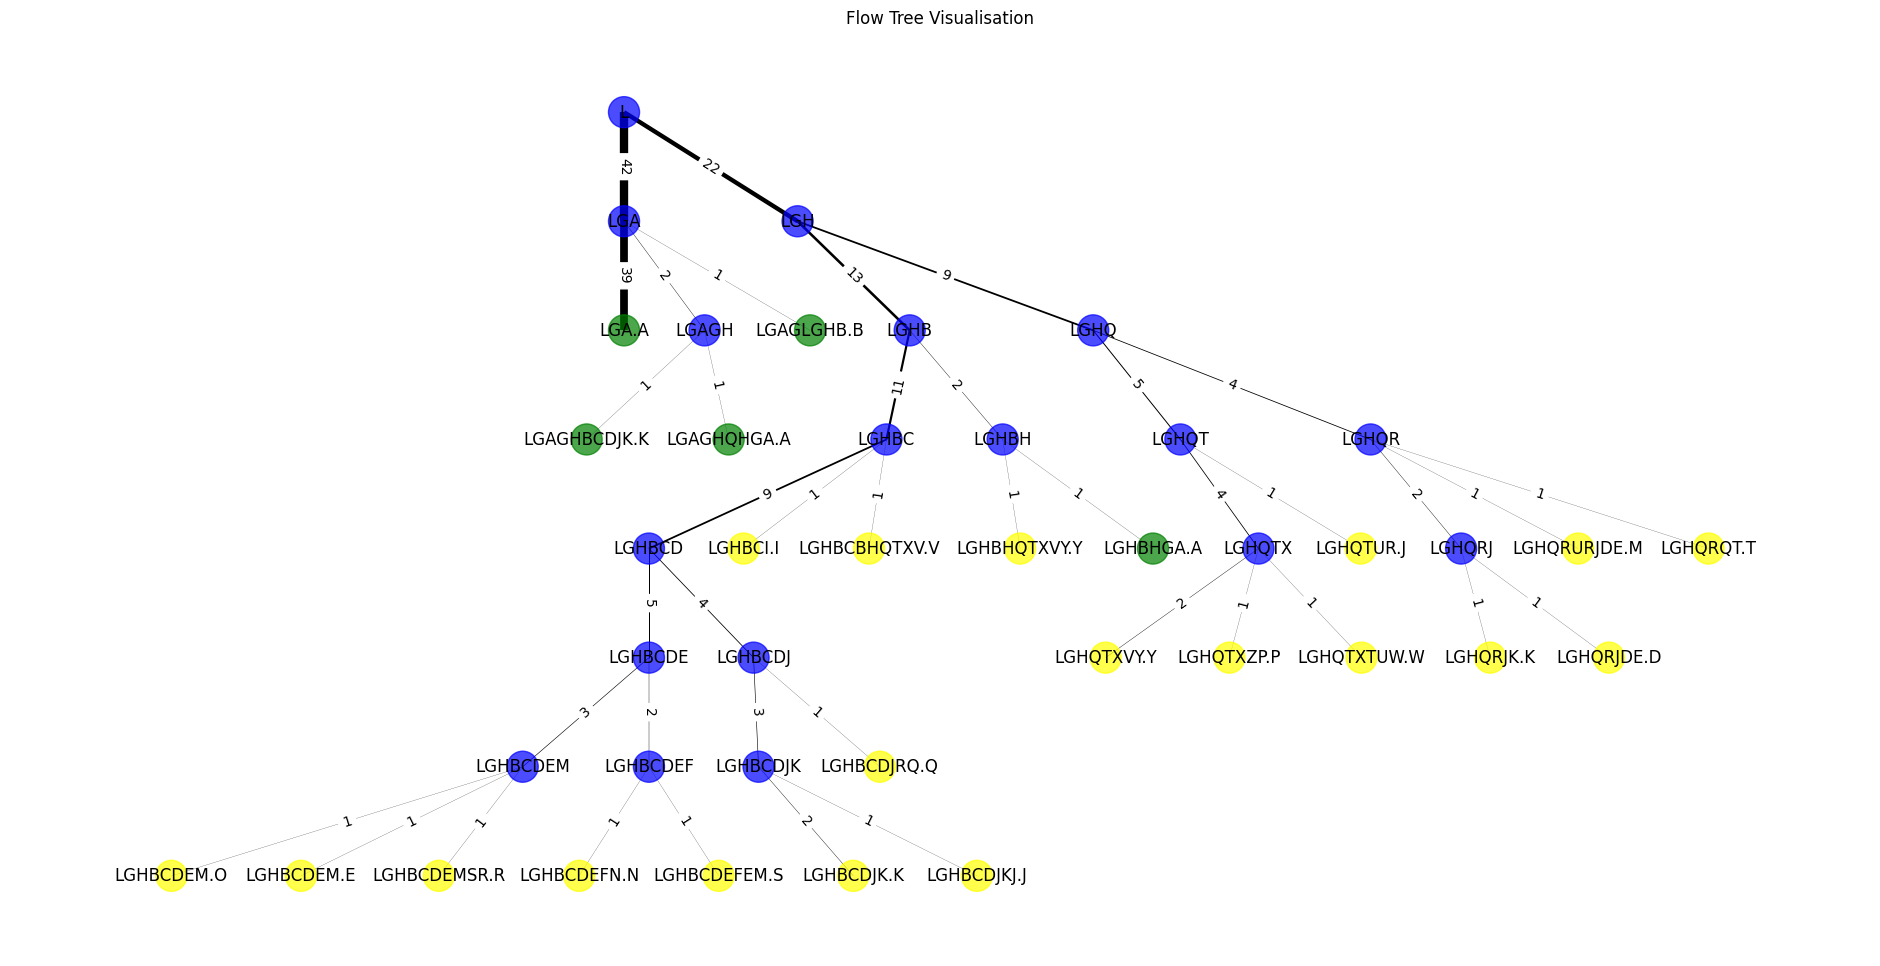

In [6]:
################################
## ONE EXAMPLE -- FROM L TO A ##
################################

START_NODE = "L"
END_NODE = "A"

trajs = generate_trajs_from_df(test_df[(test_df["StartAt"] == START_NODE) & (test_df["EndAt"] == END_NODE)])
G = generate_flow_tree_from_trajs(trajs, END_NODE=END_NODE)

plt.figure(figsize=(24,12))
ax = plt.gca()

plot_flow_tree(G, "Flow Tree Visualisation", ax)
plt.title("Flow Tree Visualisation")

plt.show()

In [7]:
## BY PATH
flow_trees = []
paths = []
accs = []
tree_dict = {}
winner_tree_dict = {}
loser_tree_dict = {}
for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    trajs = generate_trajs_from_df(group)
    G = generate_flow_tree_from_trajs(trajs, END_NODE=end_node)

    new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') # need to do for embeddings
    flow_trees.append(new_G)
    accs.append(group["path_mean_acc"].iloc[0])
    paths.append((start_node, end_node))
    tree_dict[(start_node, end_node)] = [new_G, group["path_mean_acc"].iloc[0]]

    group["accuracy"] = group["accuracy"].astype(bool)

    # WINNERS ONLY
    trajs = generate_trajs_from_df(group[group["accuracy"]])
    G = generate_flow_tree_from_trajs(trajs, END_NODE=end_node)
    winner_tree_dict[(start_node, end_node)] = G

    # LOSERS ONLY
    trajs = generate_trajs_from_df(group[~group["accuracy"]])
    G = generate_flow_tree_from_trajs(trajs, END_NODE=end_node)
    loser_tree_dict[(start_node, end_node)] = G



accs = np.array(accs)

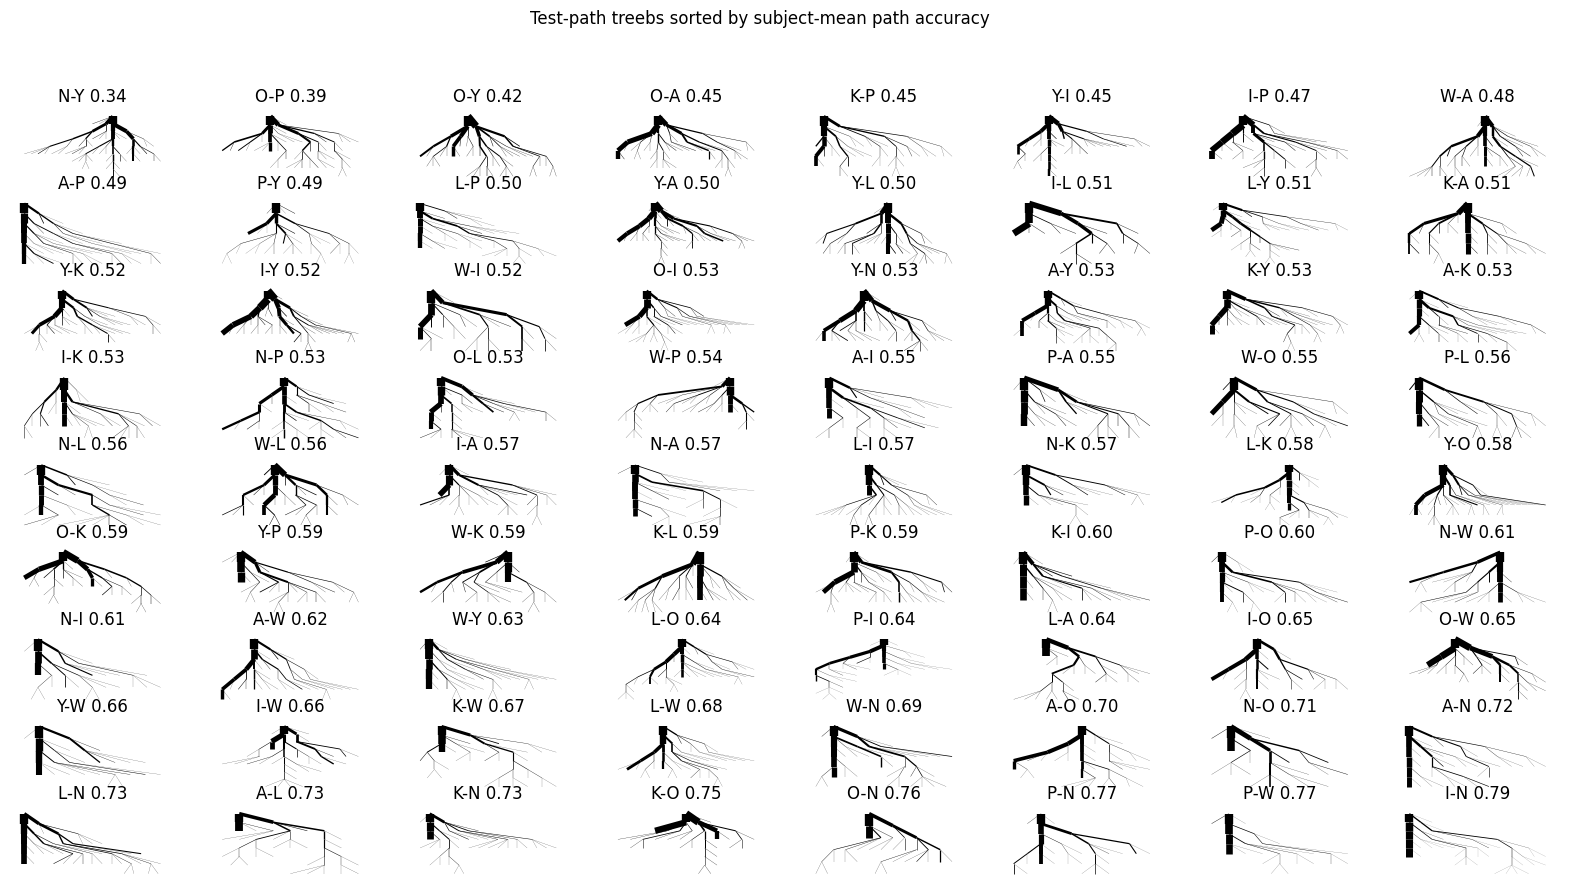

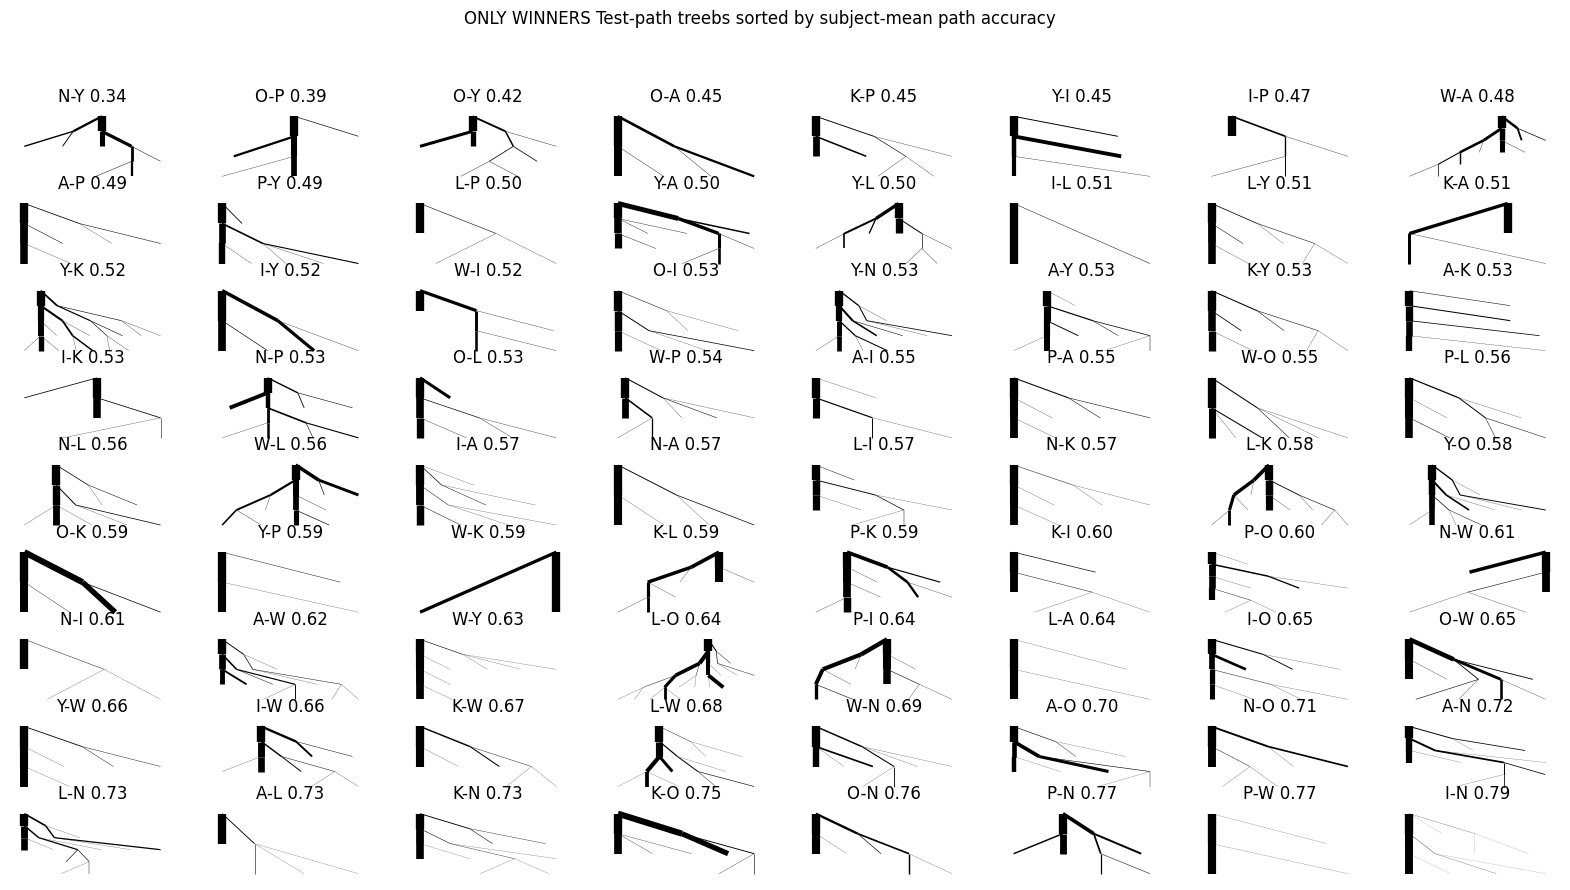

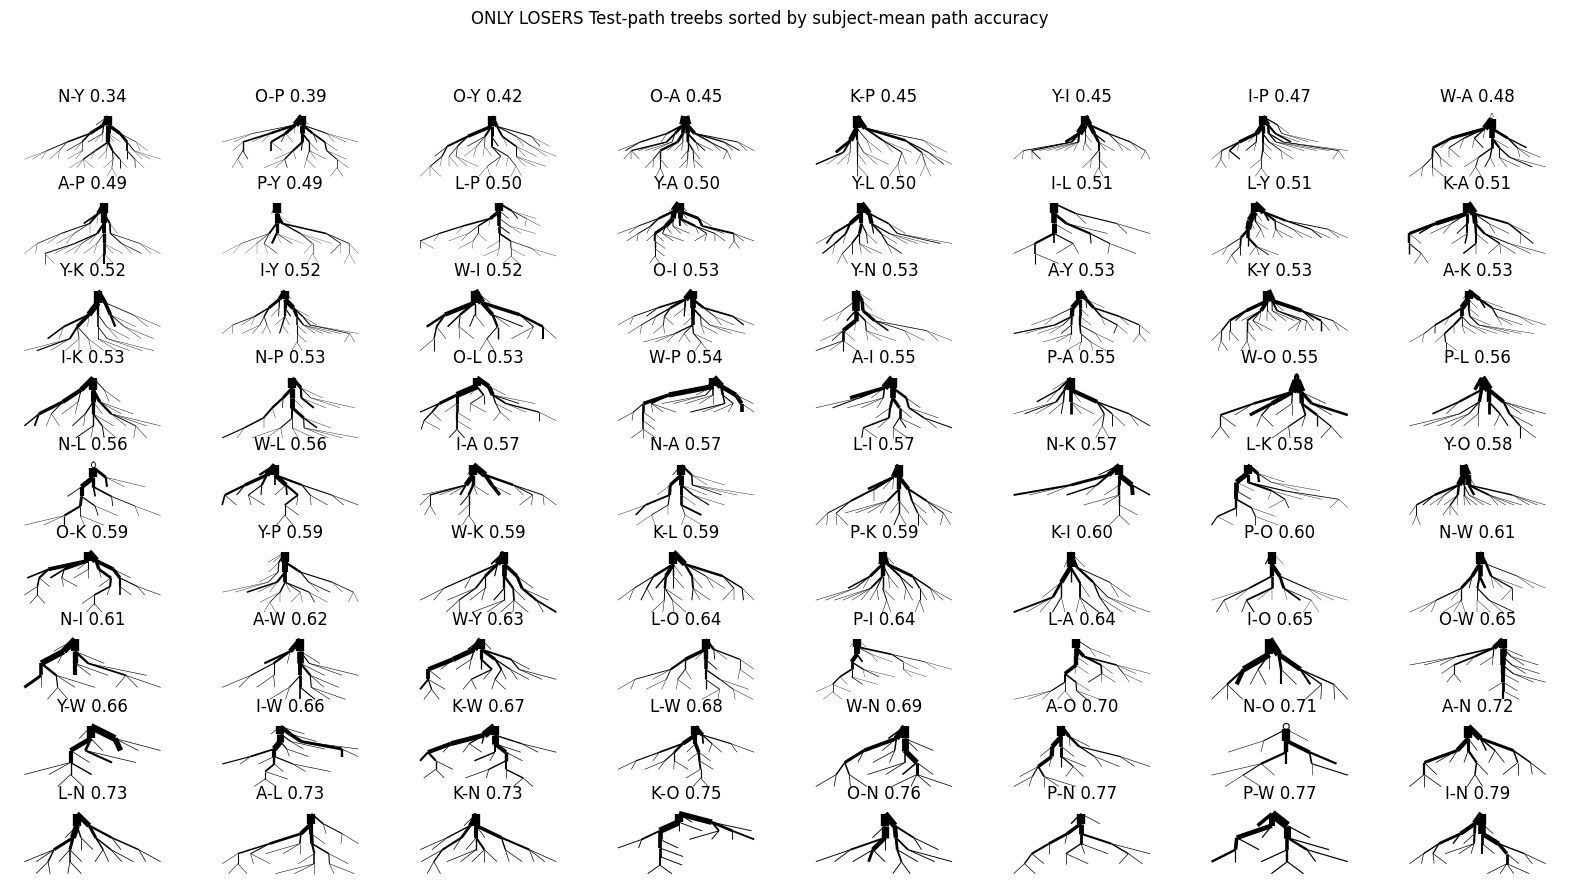

In [8]:
fig, axes = plt.subplots(9, 8, figsize=(20,10))

sorted_order = [x for x in sorted(range(len(accs)), key=lambda x: accs[x])]
c=0
for i, tree_index in enumerate(sorted_order):
    G = flow_trees[tree_index]
    
    ax = axes[i // 8][i % 8]
    plot_flow_tree(G, f"{'-'.join(paths[tree_index])} {accs[tree_index]:.2f}", ax, just_edges=True)

fig.suptitle("Test-path treebs sorted by subject-mean path accuracy")
fig.savefig("figures/test_flow_trees_by_acc.png")

plt.show()


fig, axes = plt.subplots(9, 8, figsize=(20,10))

sorted_order = [x for x in sorted(range(len(accs)), key=lambda x: accs[x])]
c=0
for i, tree_index in enumerate(sorted_order):
    G = winner_tree_dict[paths[tree_index]]
    
    ax = axes[i // 8][i % 8]
    plot_flow_tree(G, f"{'-'.join(paths[tree_index])} {accs[tree_index]:.2f}", ax, just_edges=True)

fig.suptitle("ONLY WINNERS Test-path treebs sorted by subject-mean path accuracy")
fig.savefig("figures/test_flow_trees_by_acc-only_winners.png")

plt.show()


fig, axes = plt.subplots(9, 8, figsize=(20,10))

sorted_order = [x for x in sorted(range(len(accs)), key=lambda x: accs[x])]
c=0
for i, tree_index in enumerate(sorted_order):
    G = loser_tree_dict[paths[tree_index]]
    
    ax = axes[i // 8][i % 8]
    plot_flow_tree(G, f"{'-'.join(paths[tree_index])} {accs[tree_index]:.2f}", ax, just_edges=True)

fig.suptitle("ONLY LOSERS Test-path treebs sorted by subject-mean path accuracy")
fig.savefig("figures/test_flow_trees_by_acc-only_losers.png")

plt.show()


# compare to baseline
#   of min path distance!

### Compare winners to losers

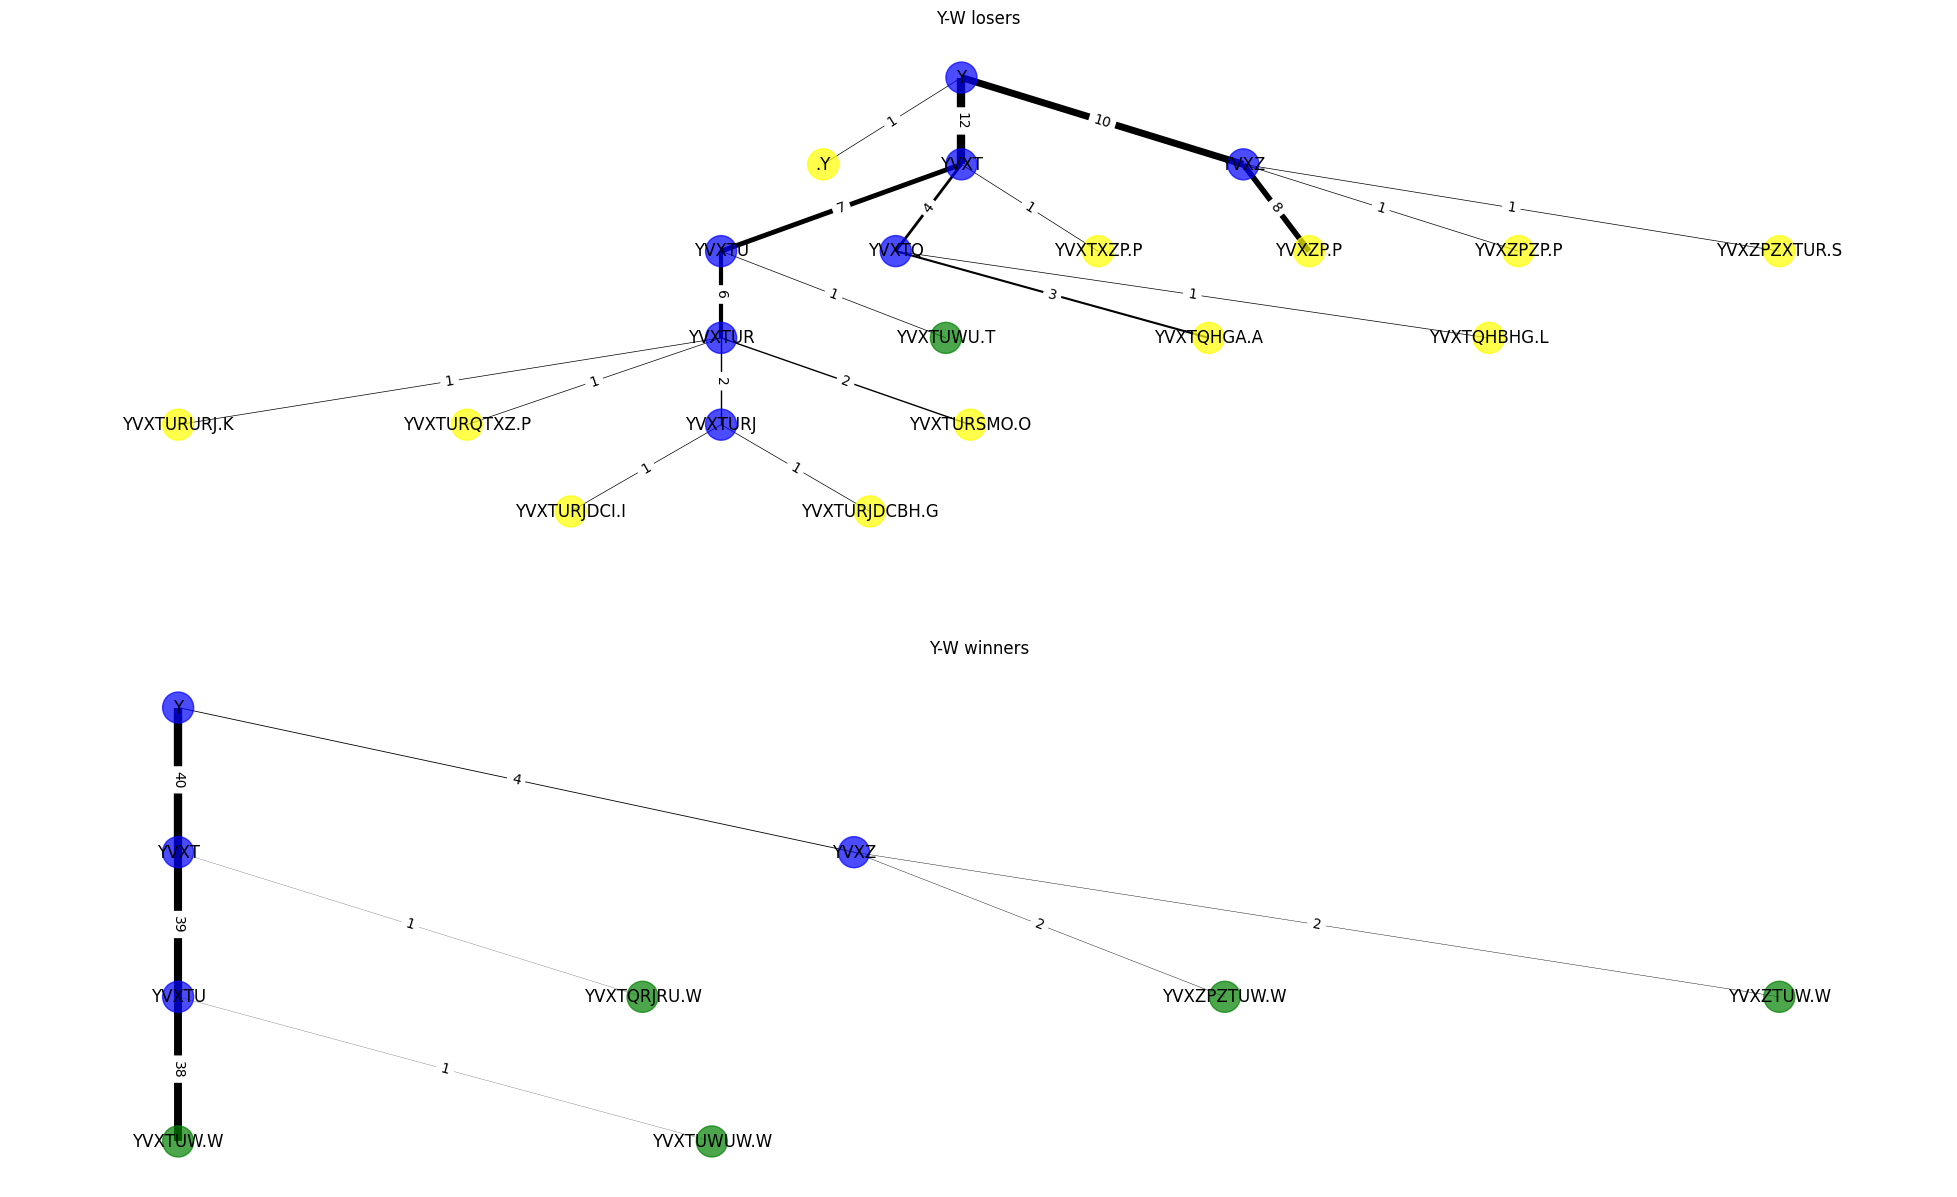

In [74]:
fig, axes = plt.subplots(2, 1, figsize=(25,15))

nodea, nodeb = "Y", "W"

G = loser_tree_dict[(nodea, nodeb)]
plot_flow_tree(G, f"{nodea}-{nodeb} losers", axes[0])

G = winner_tree_dict[(nodea, nodeb)]
plot_flow_tree(G, f"{nodea}-{nodeb} winners", axes[1])

plt.show()

#### Plot by pairs

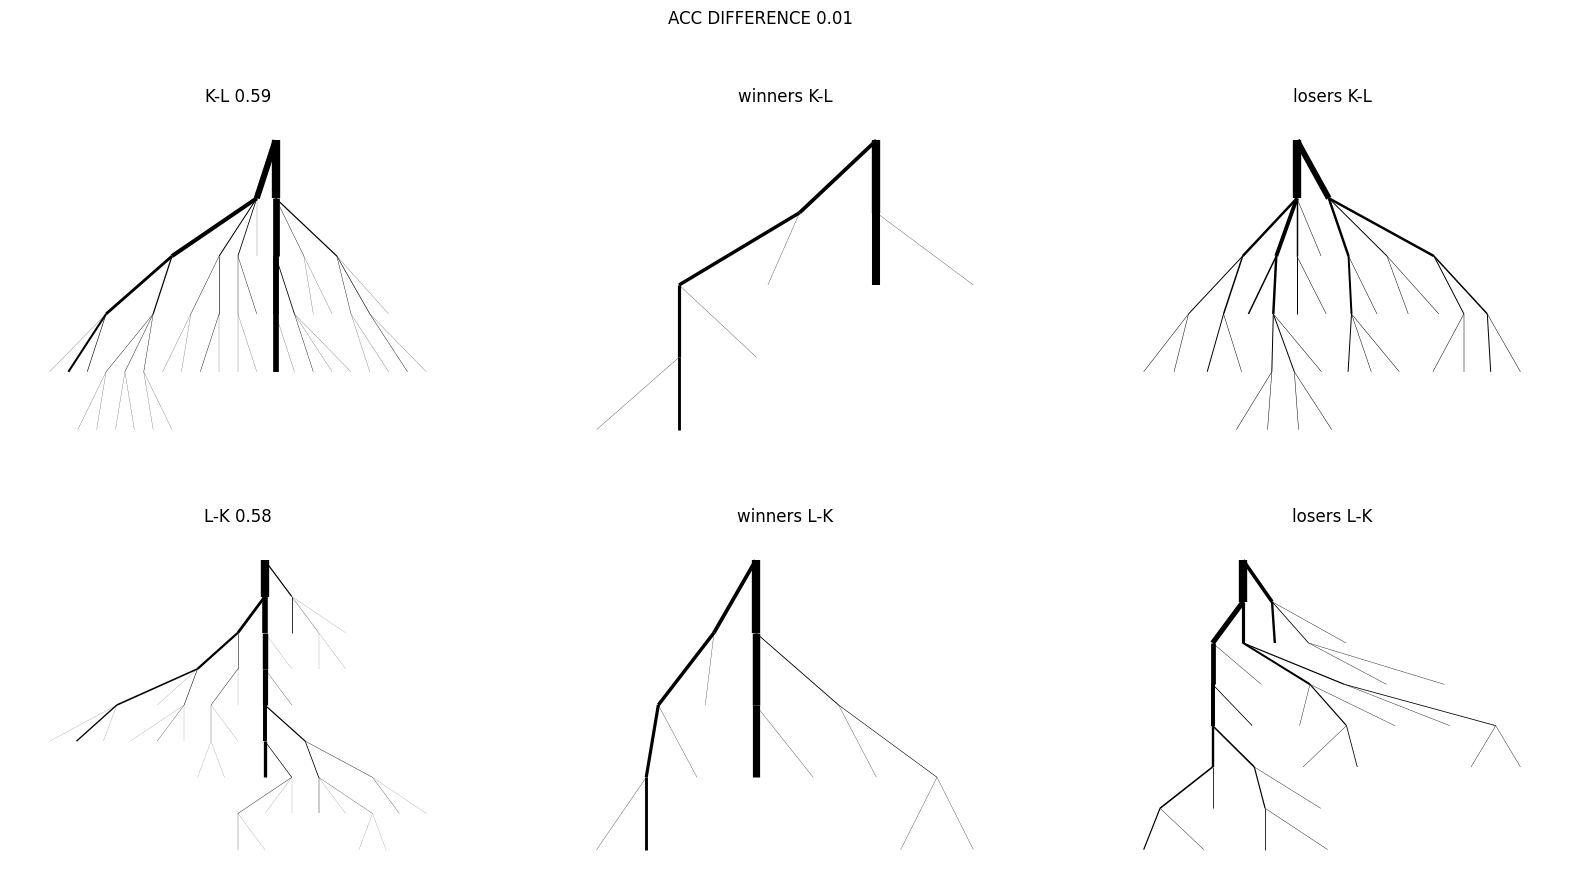

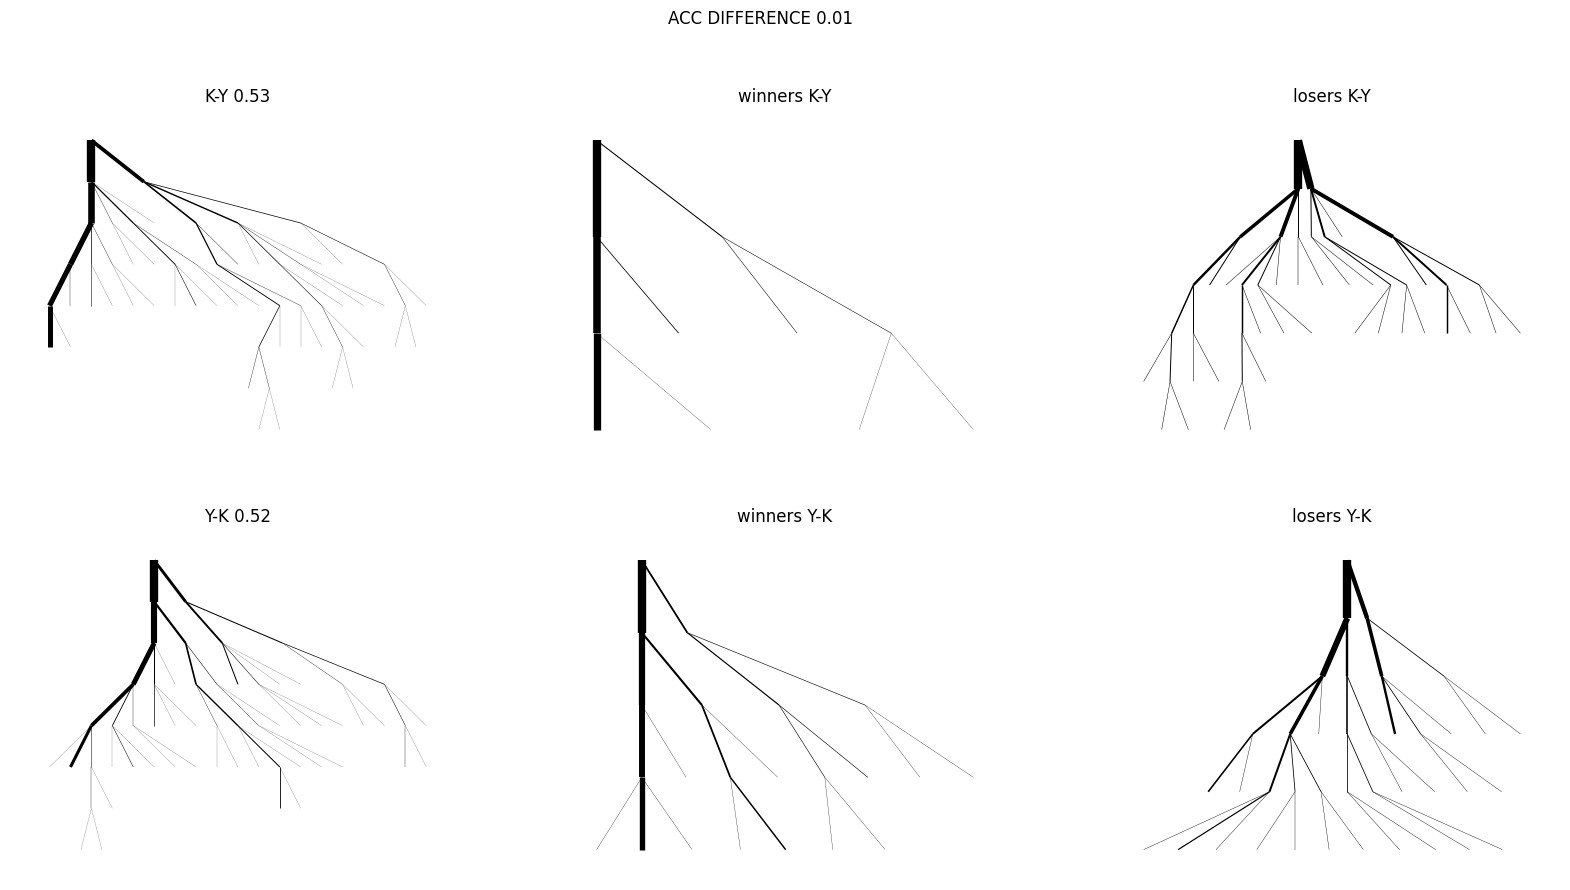

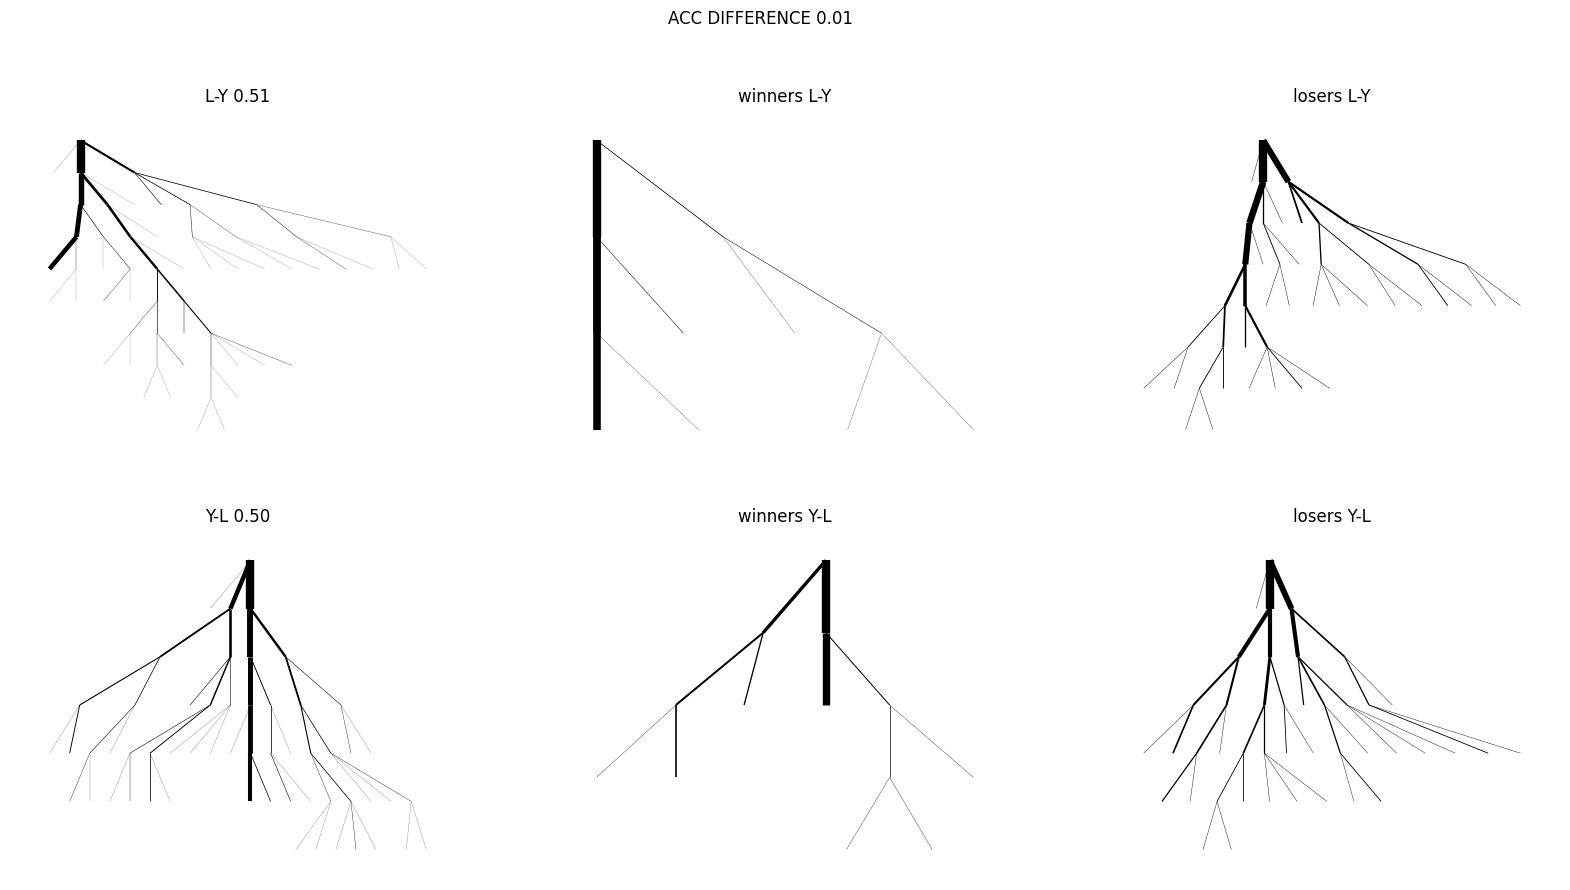

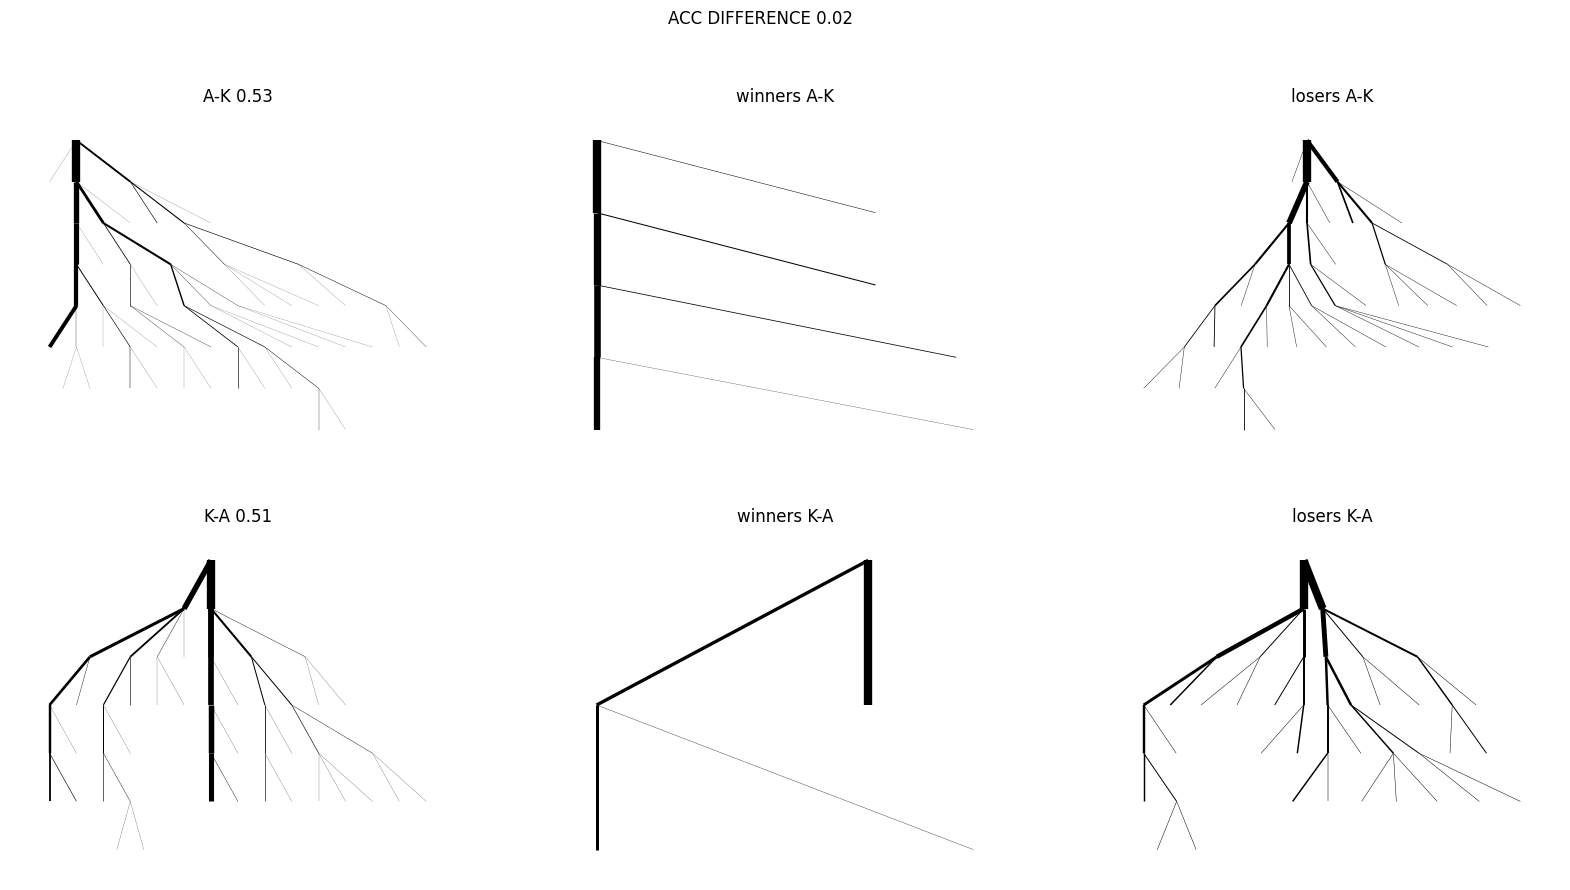

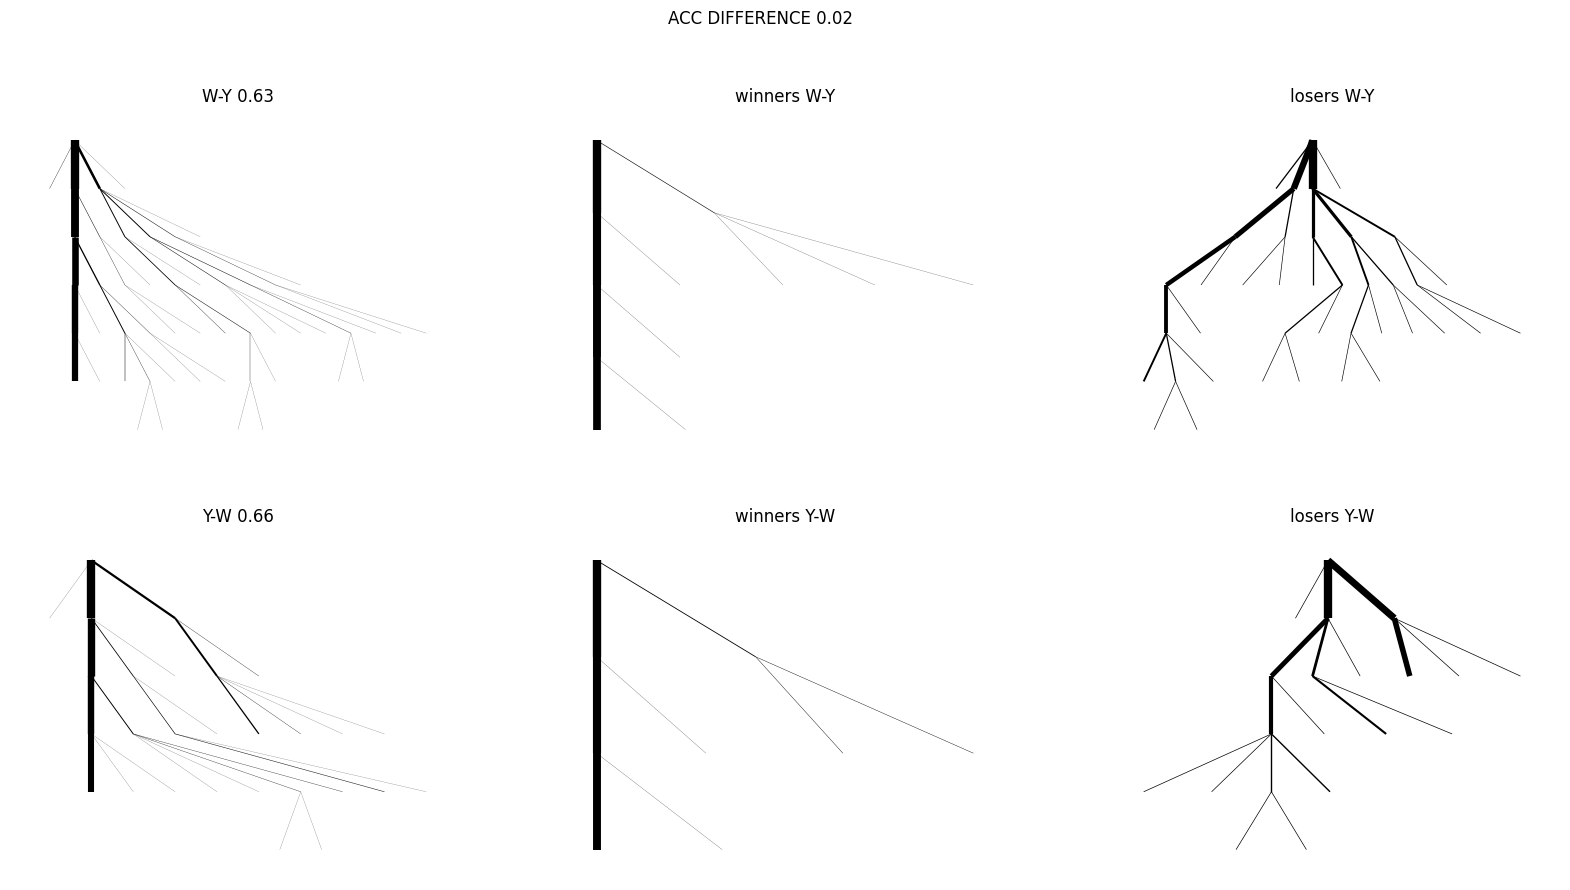

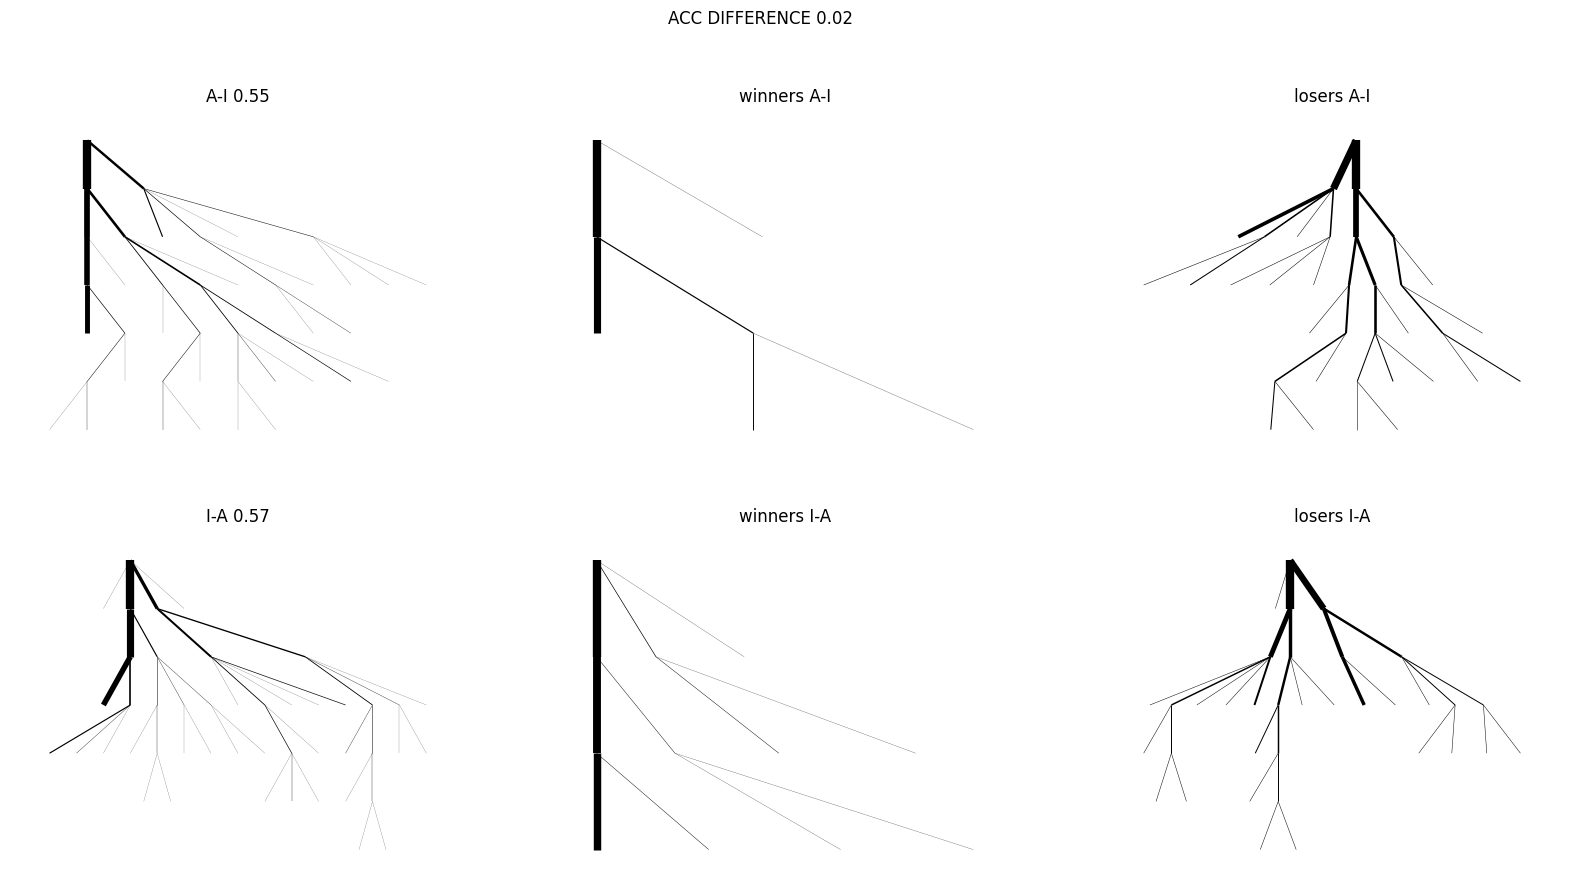

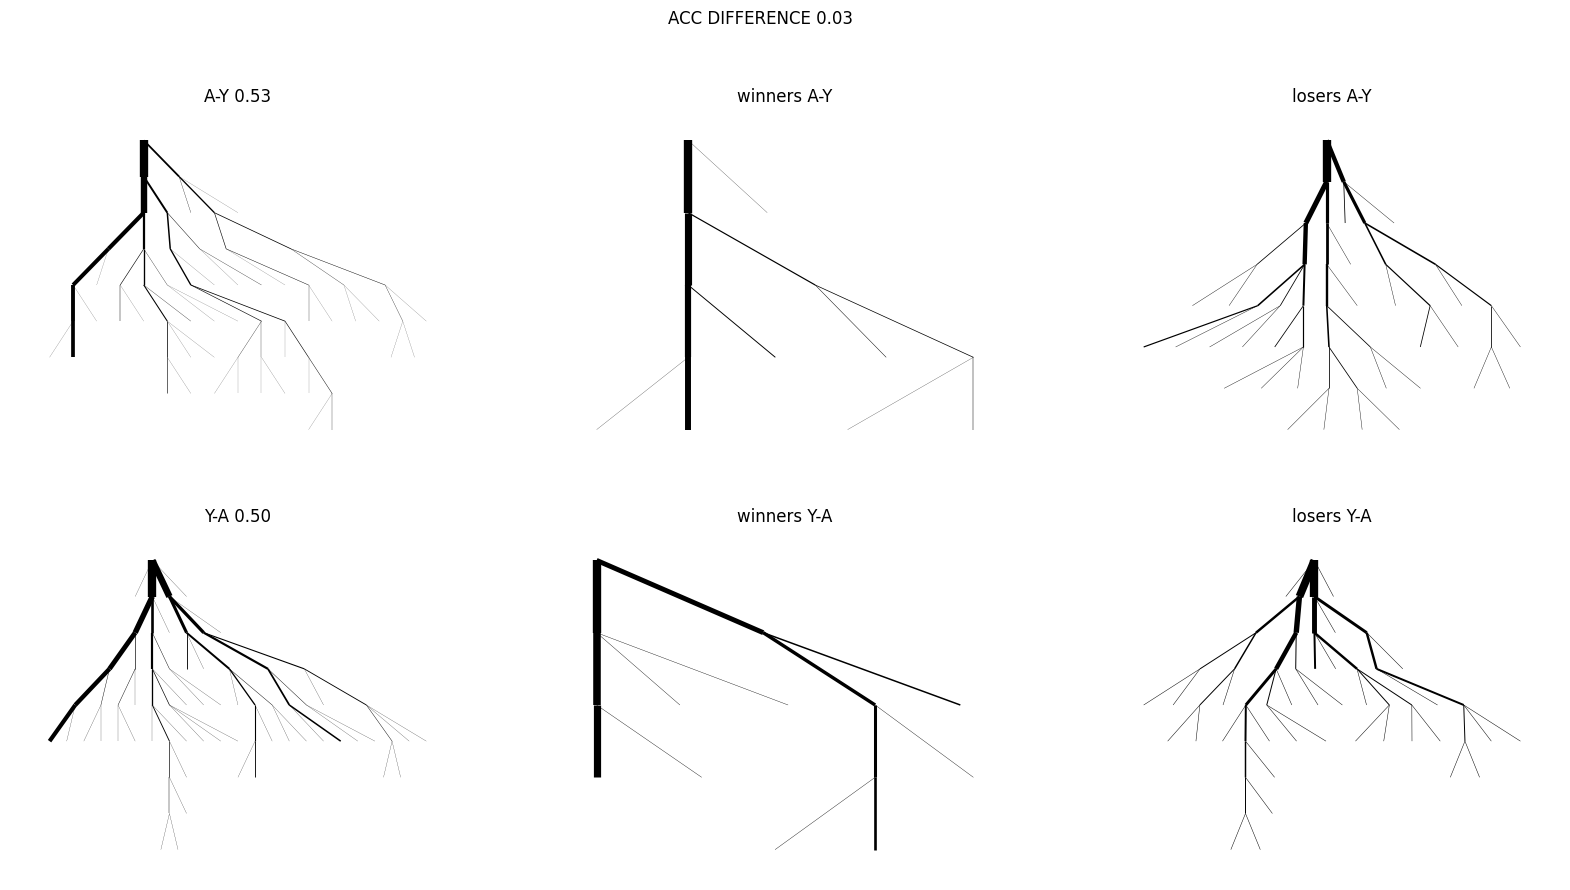

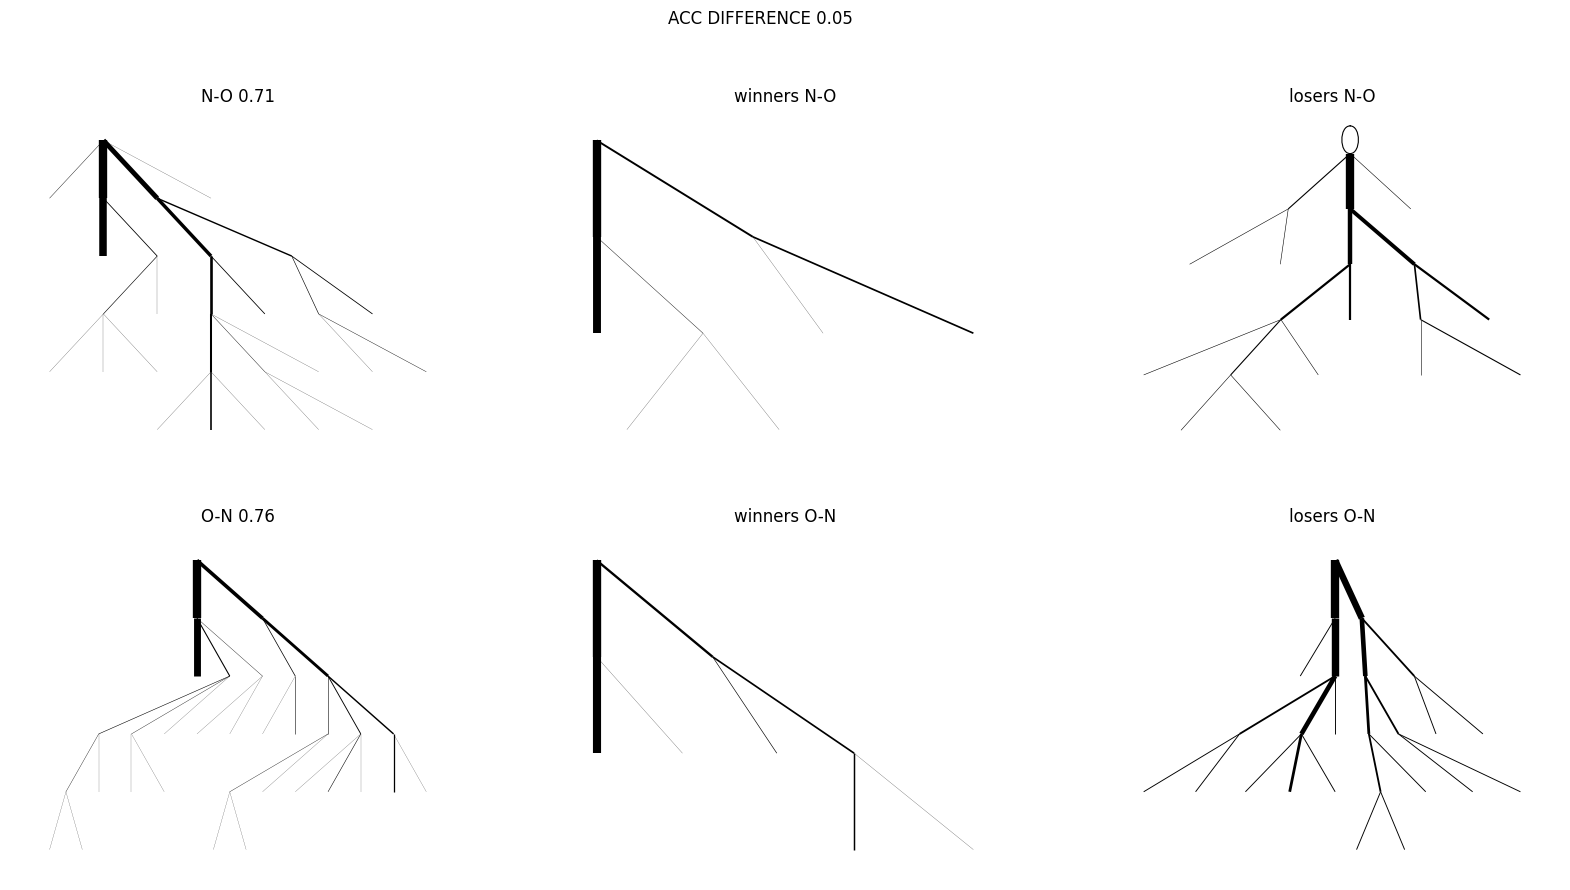

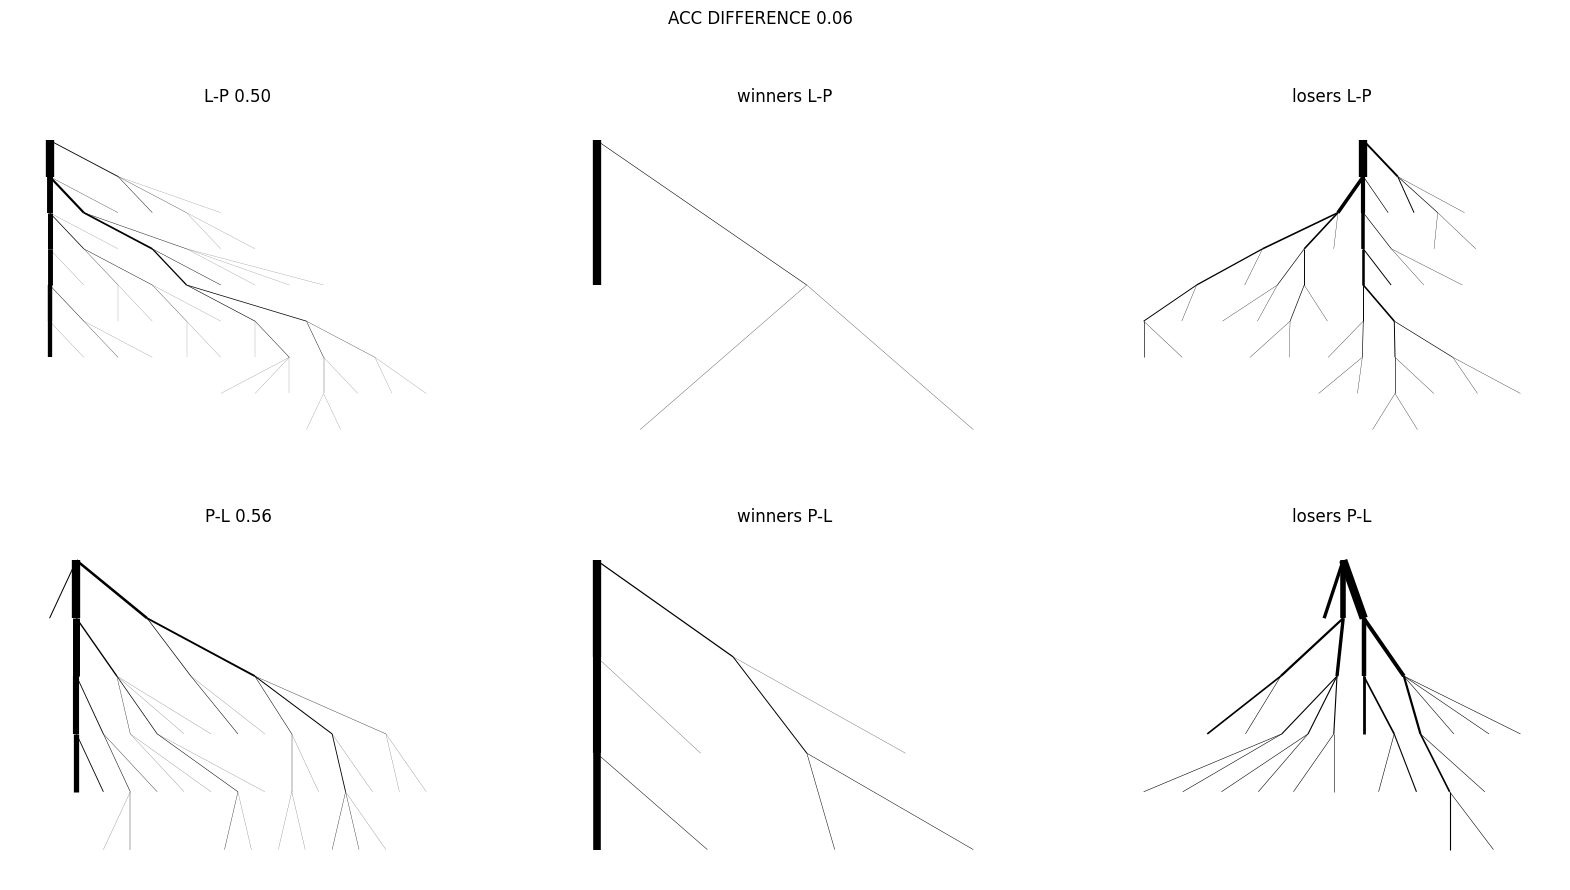

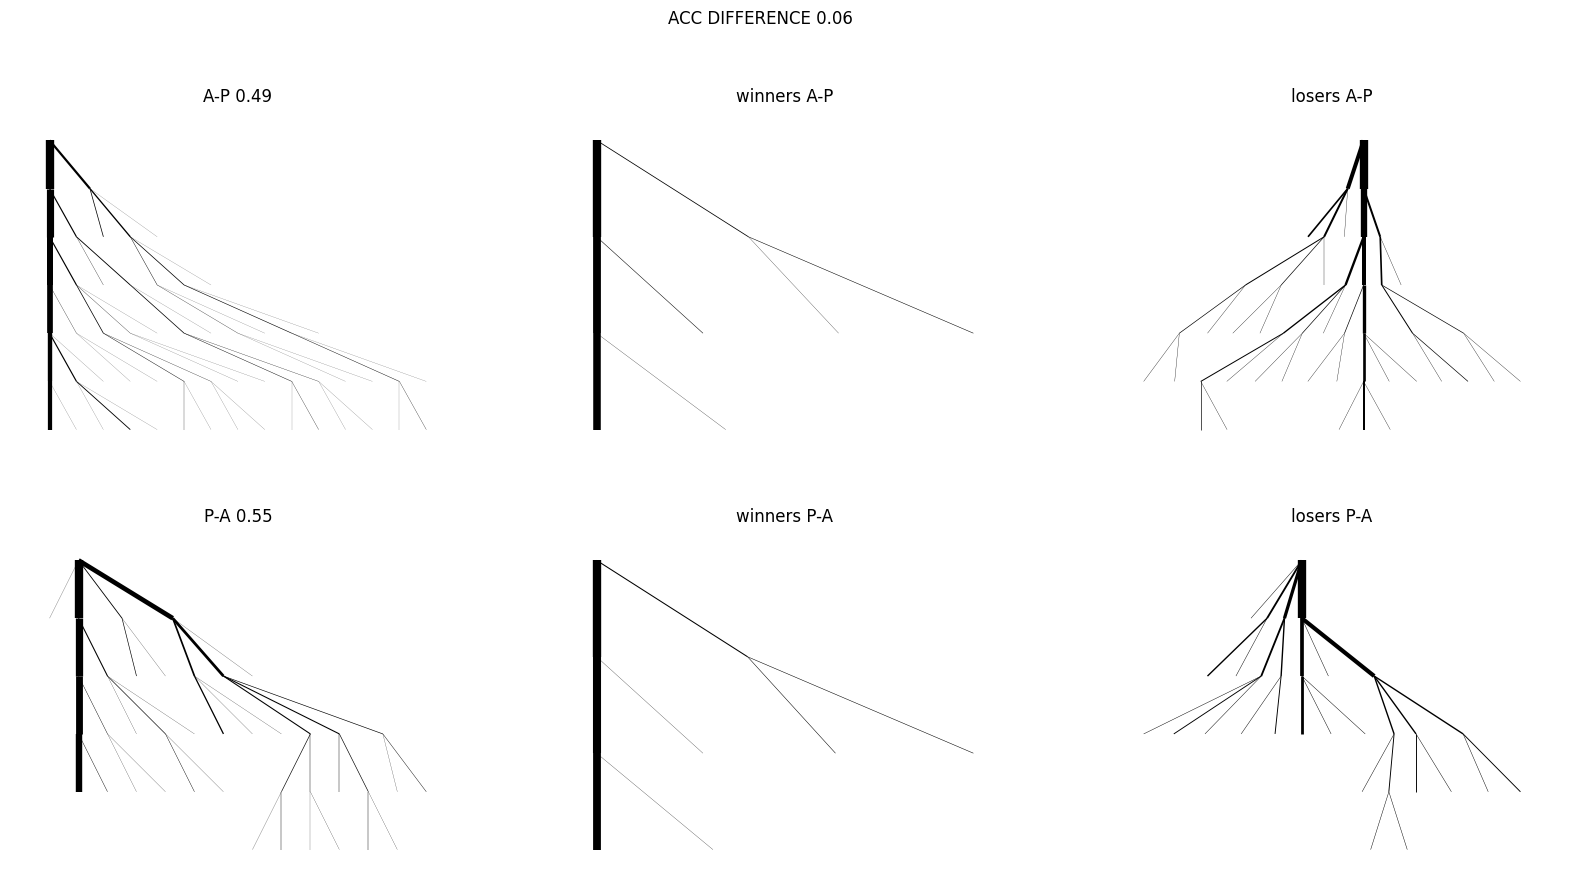

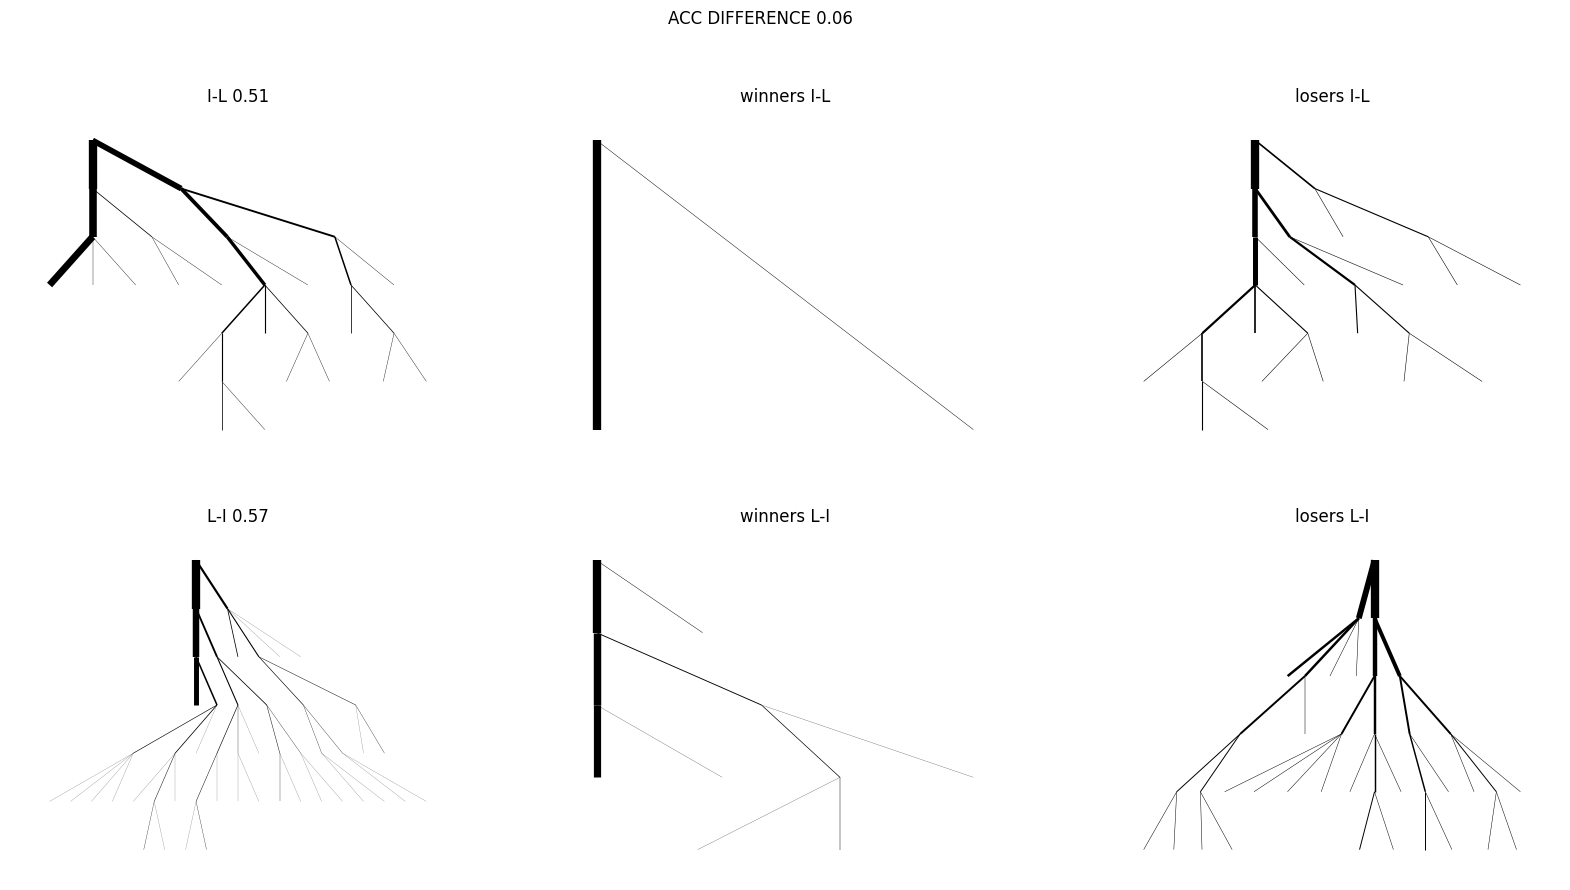

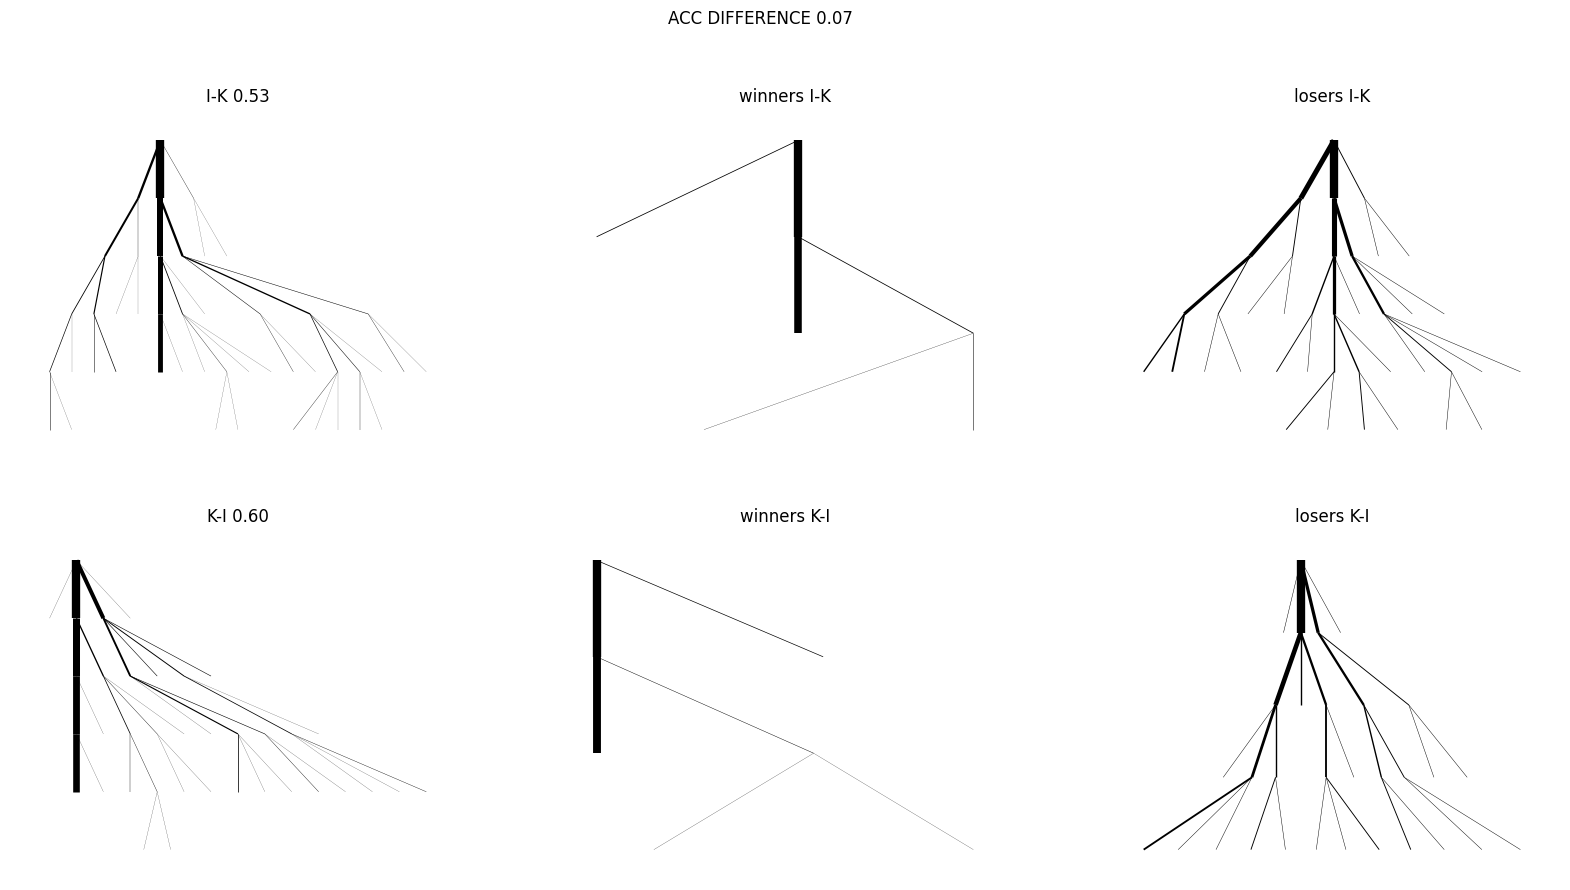

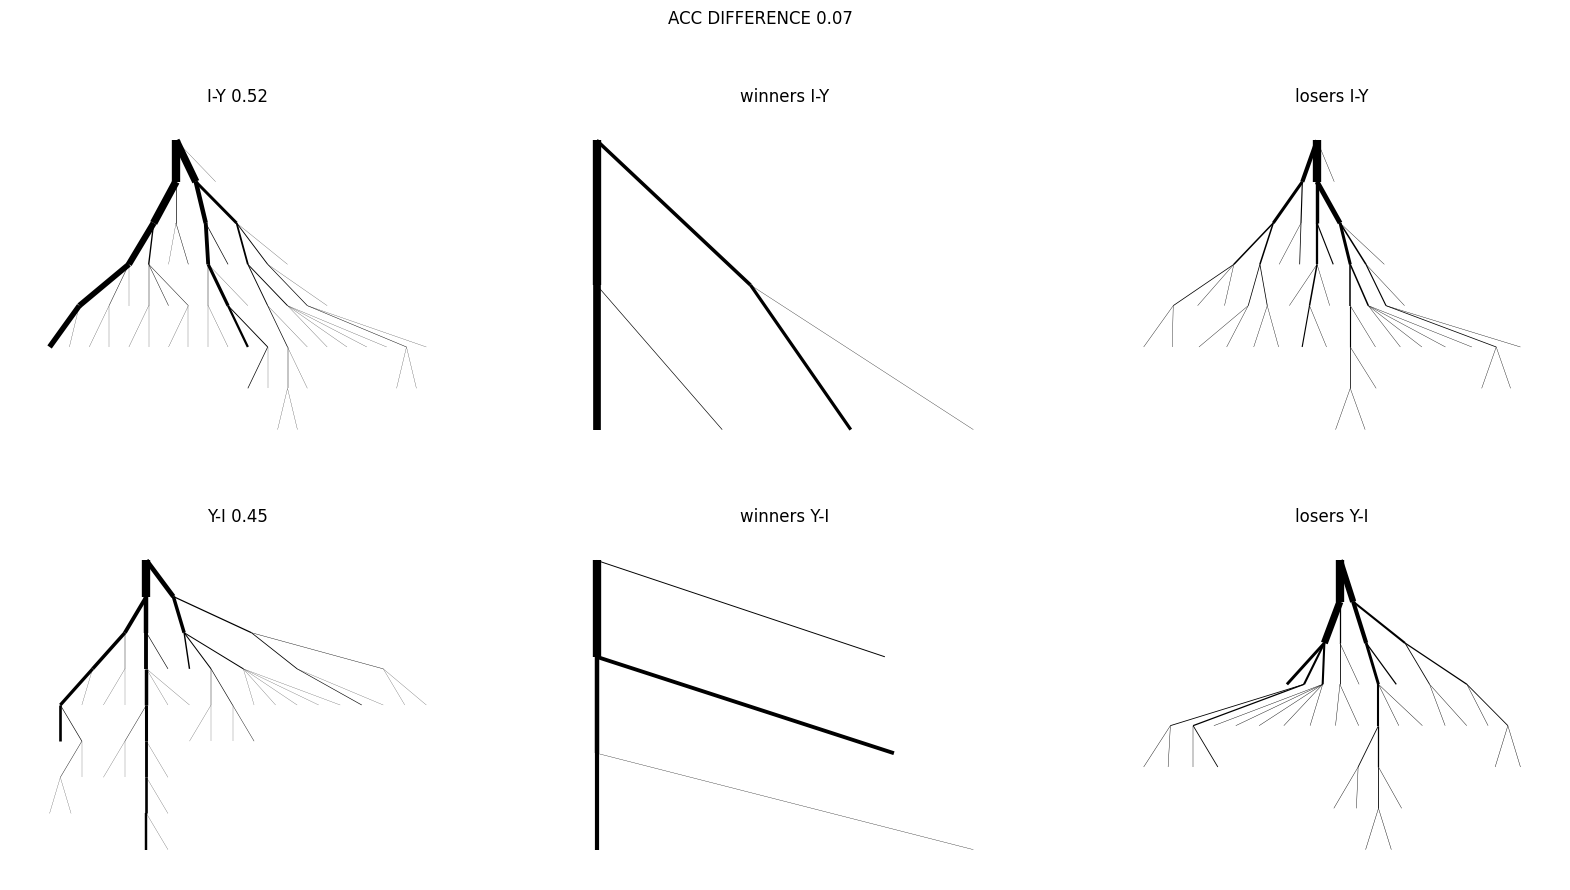

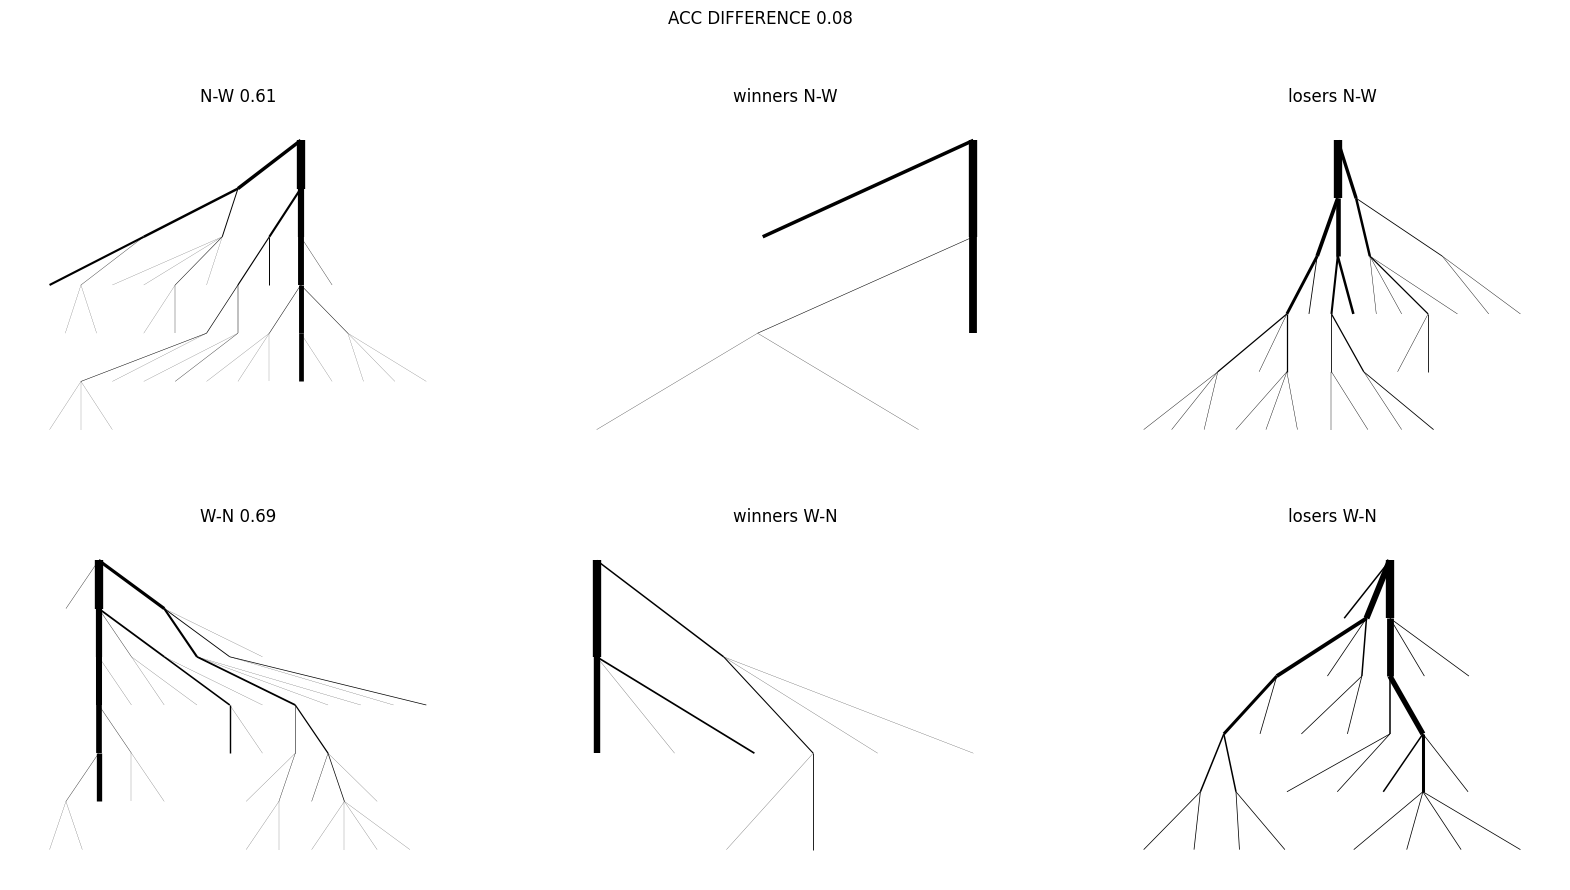

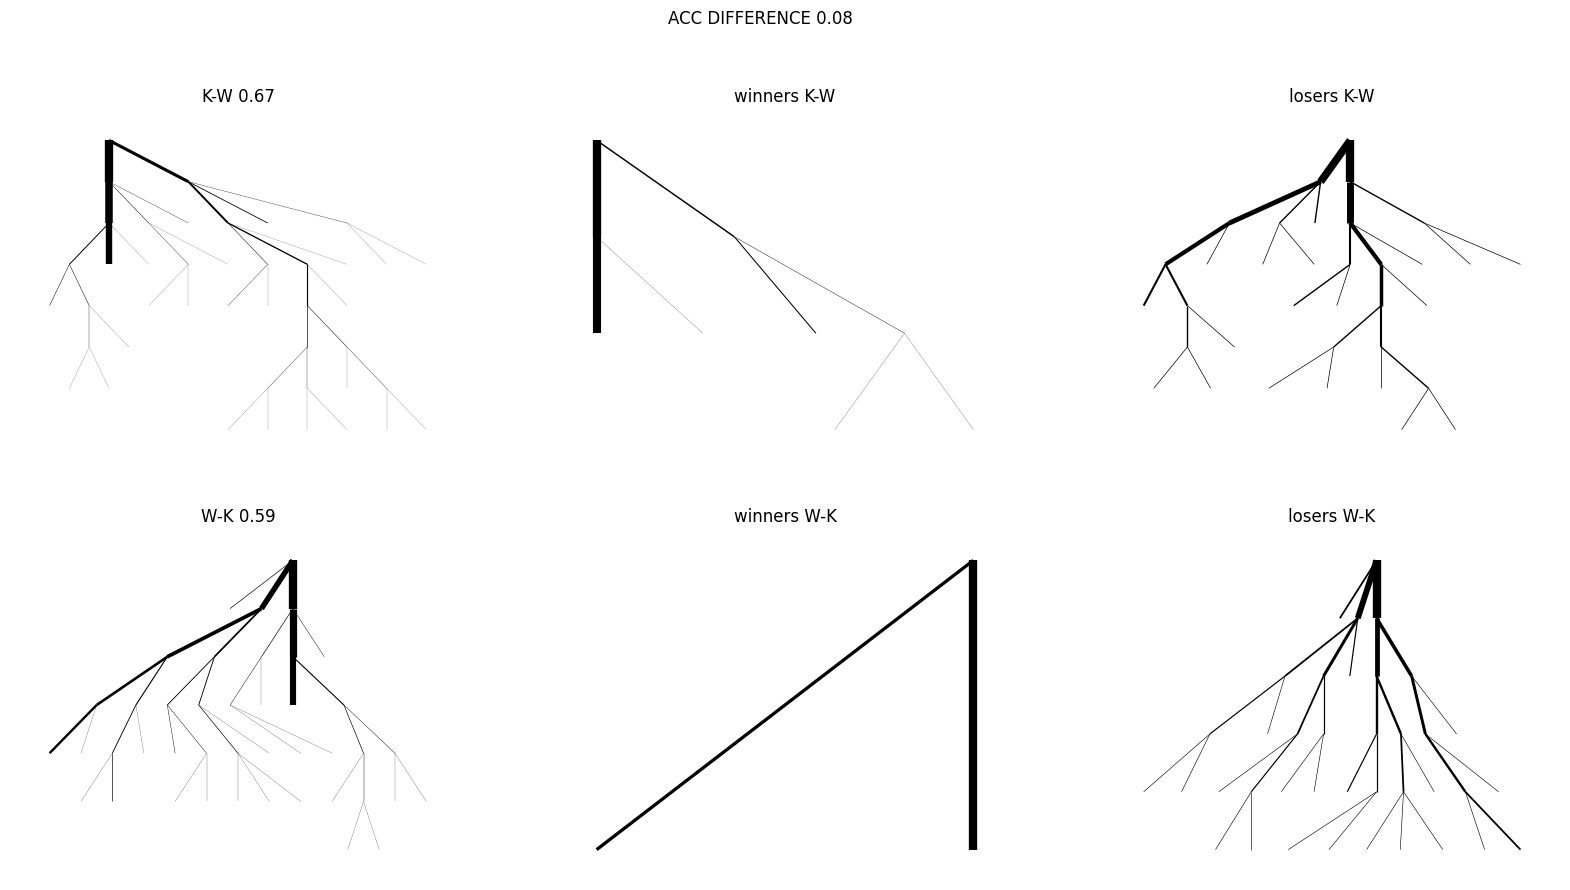

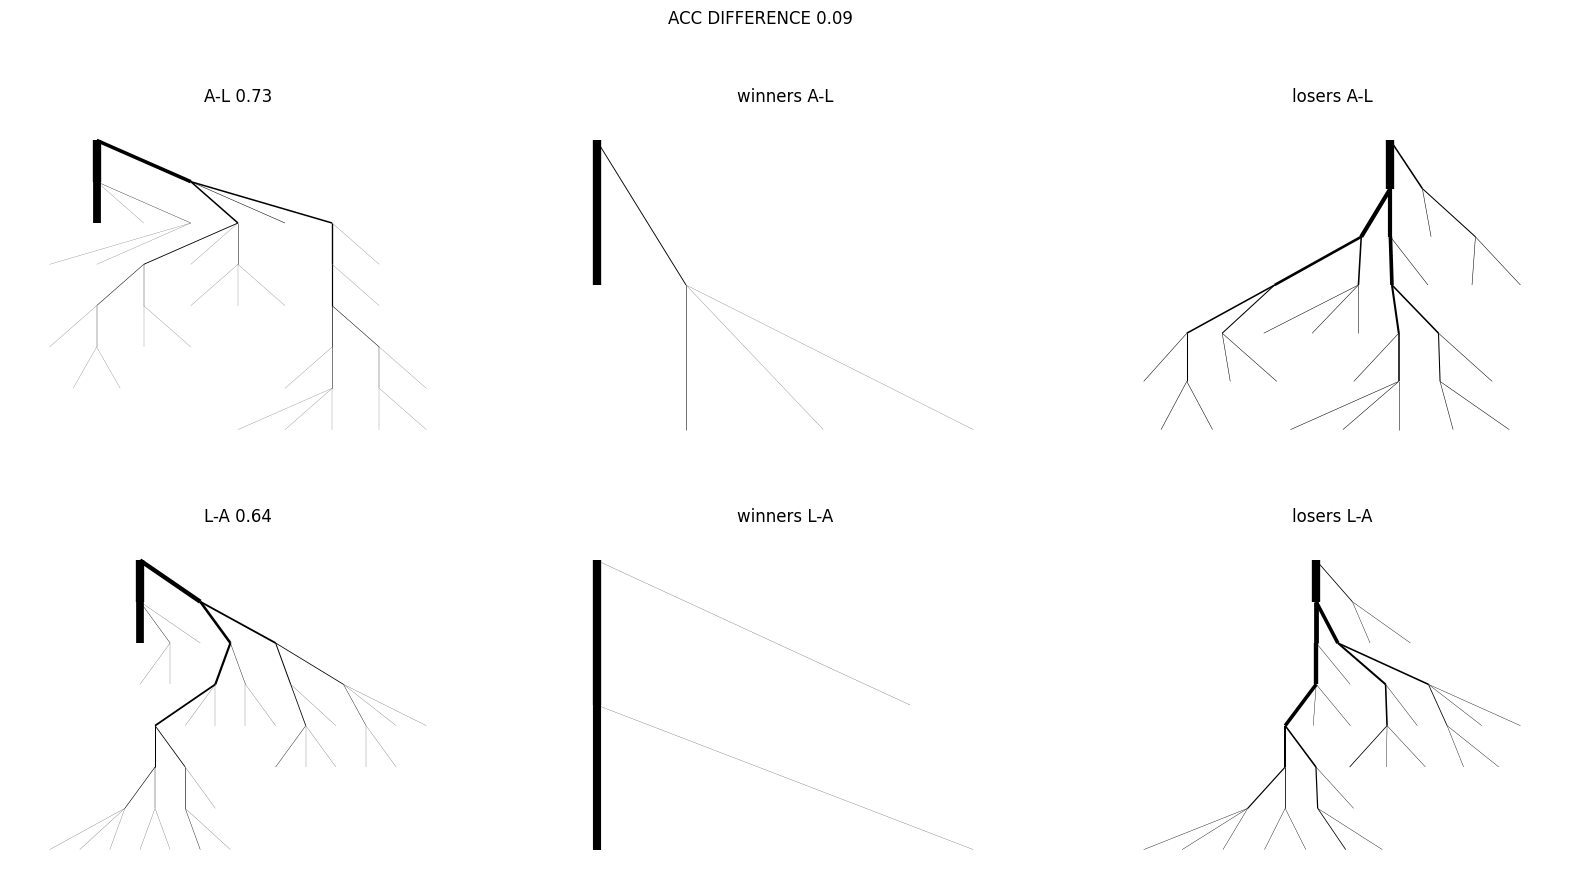

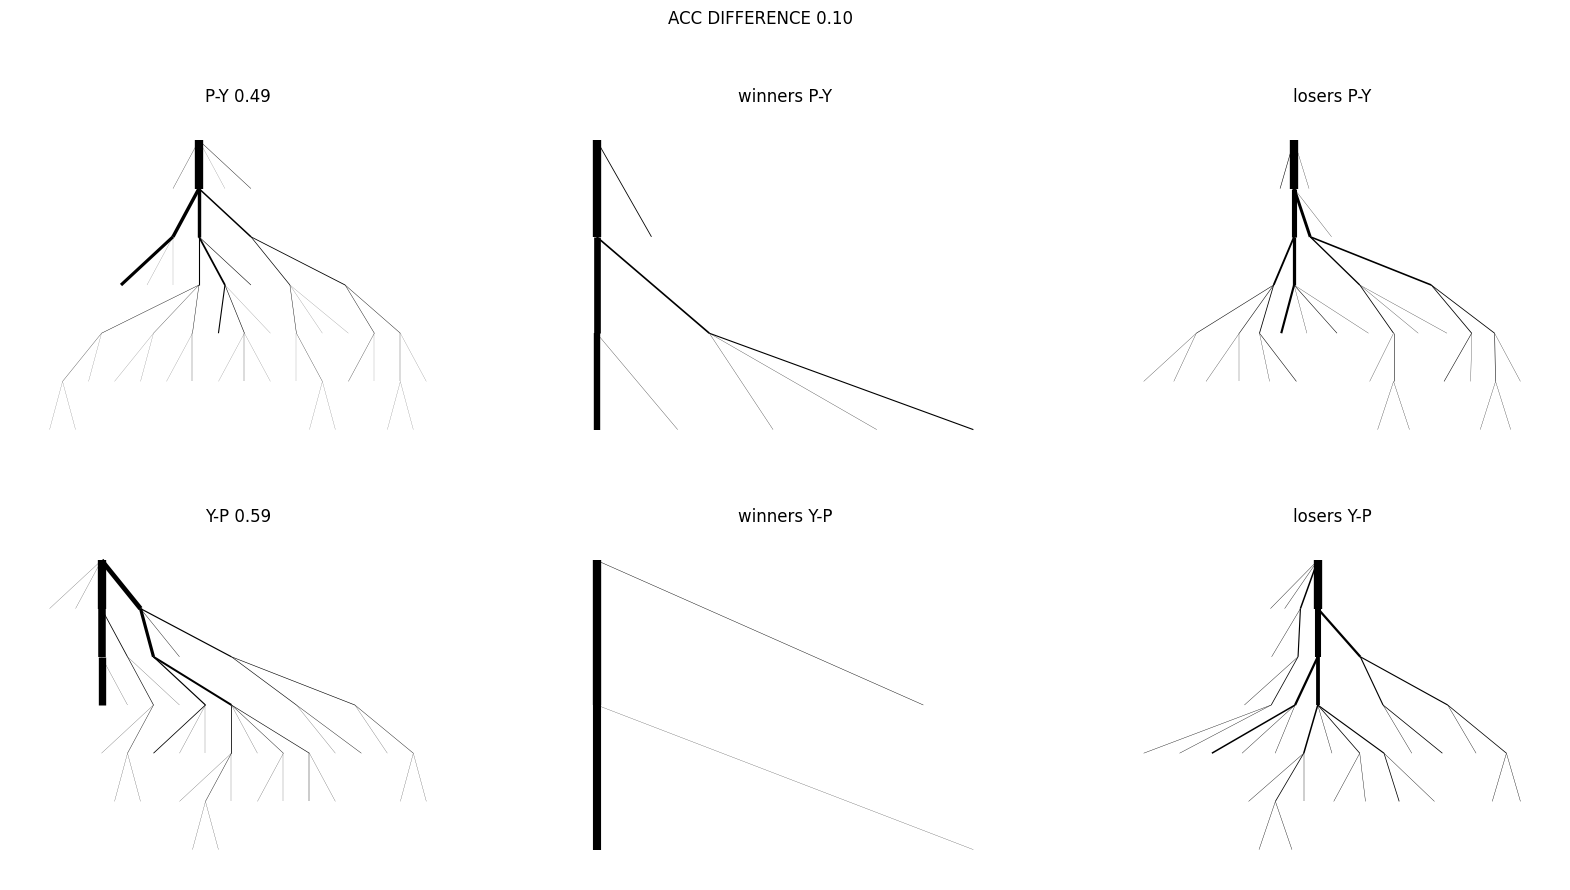

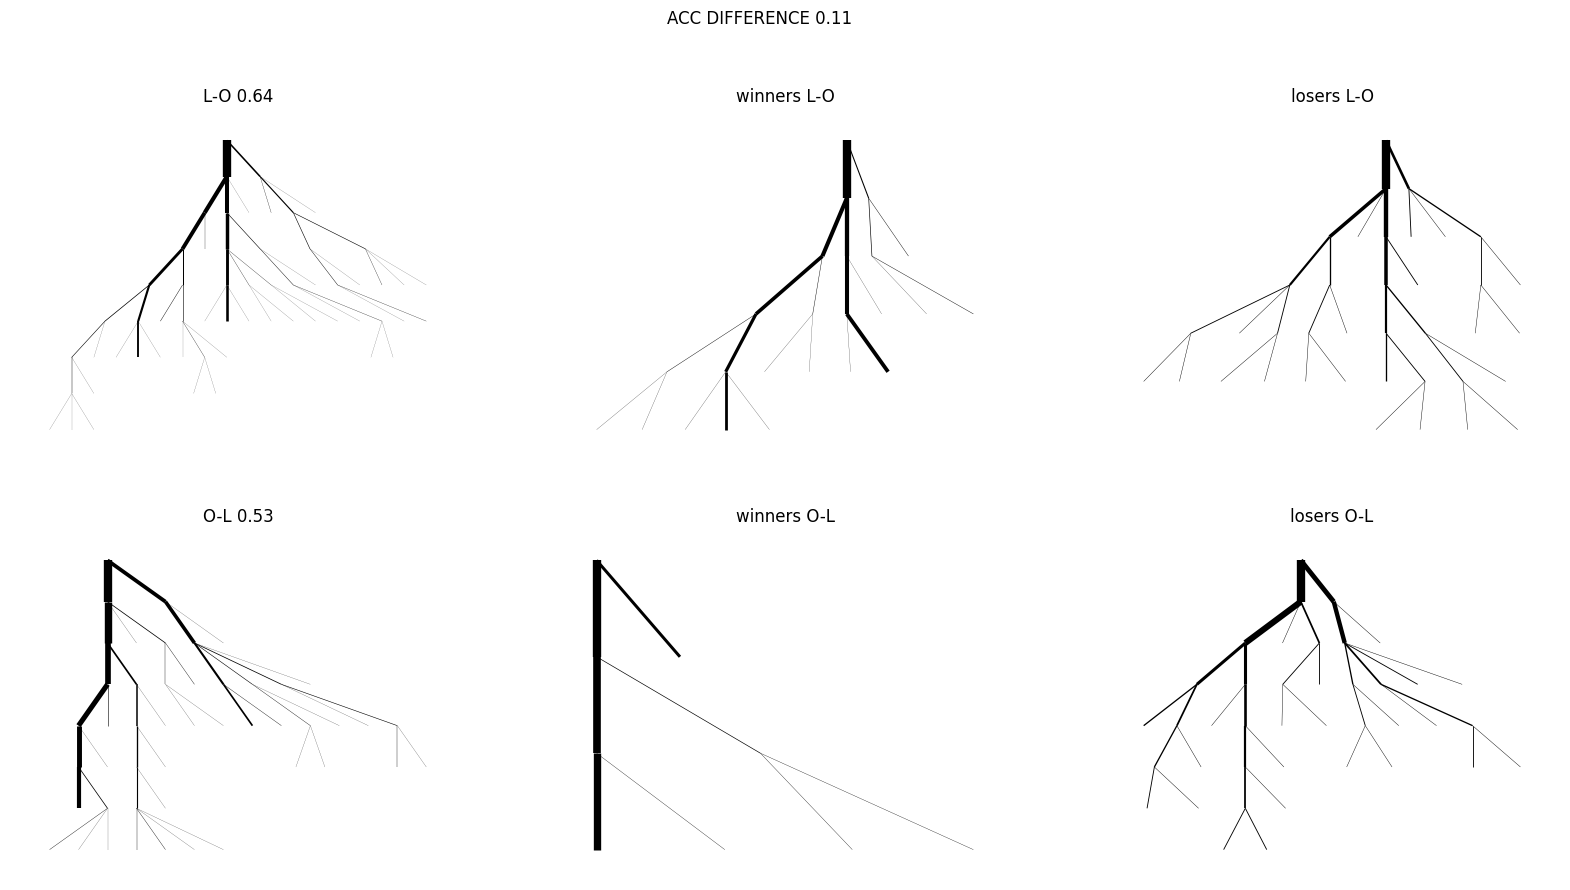

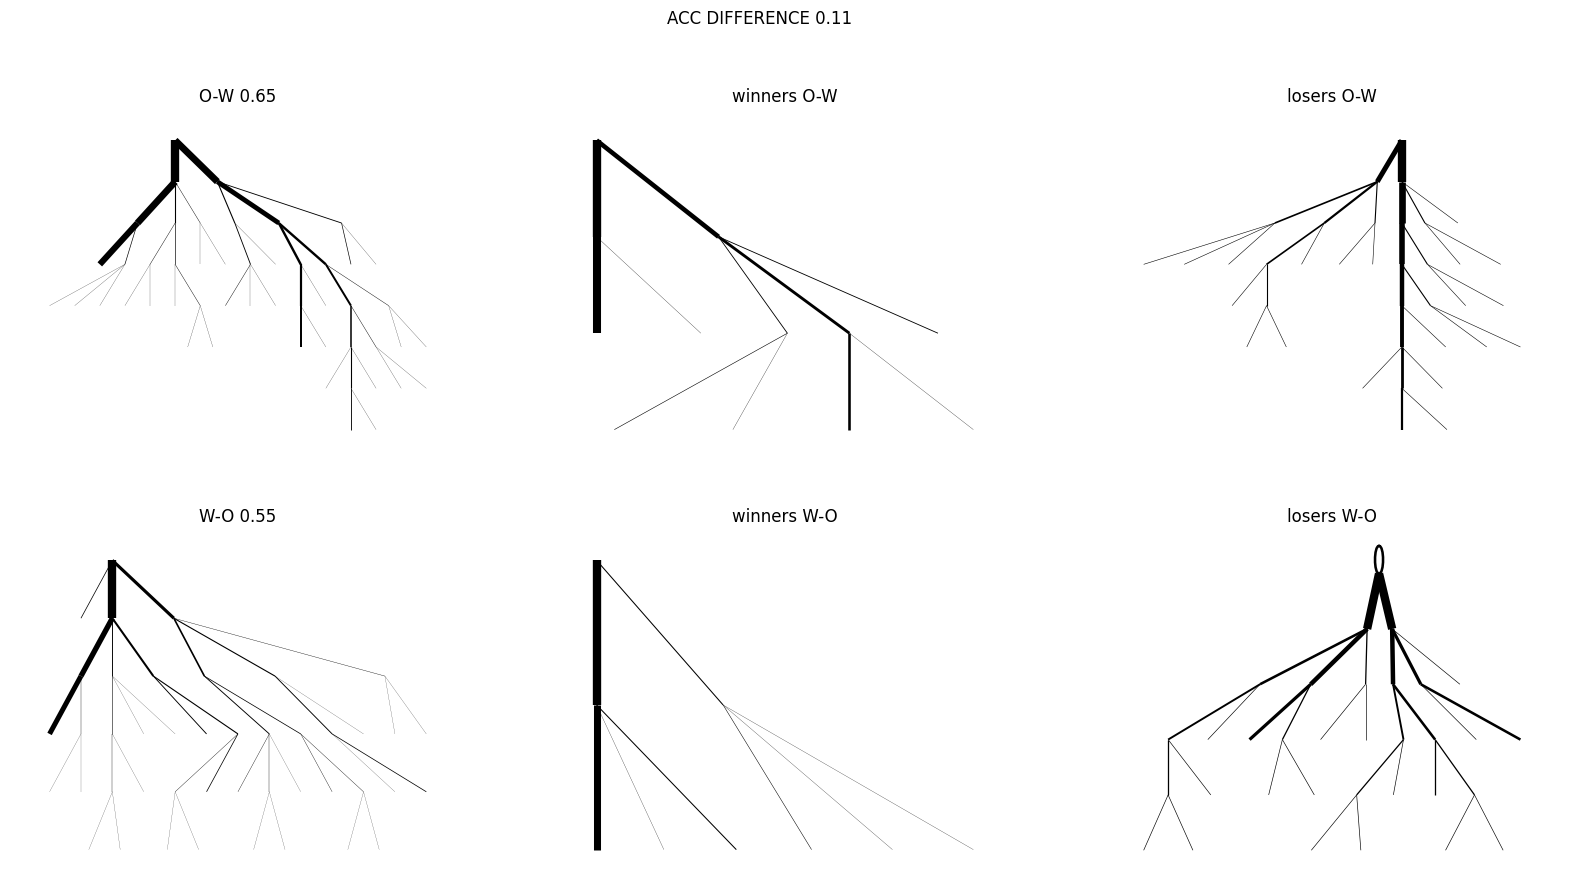

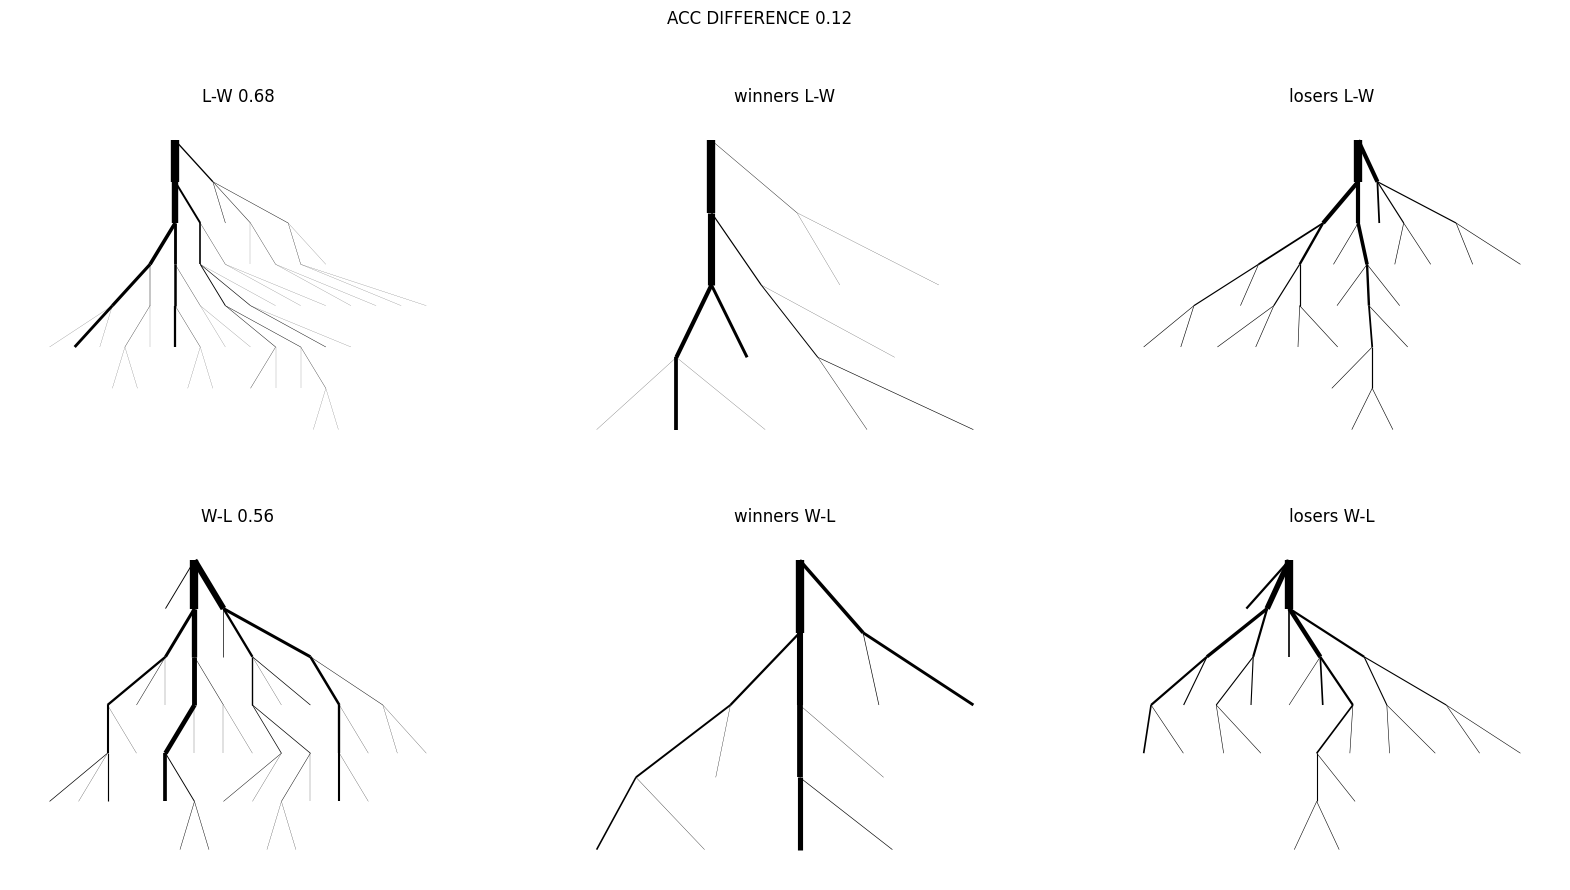

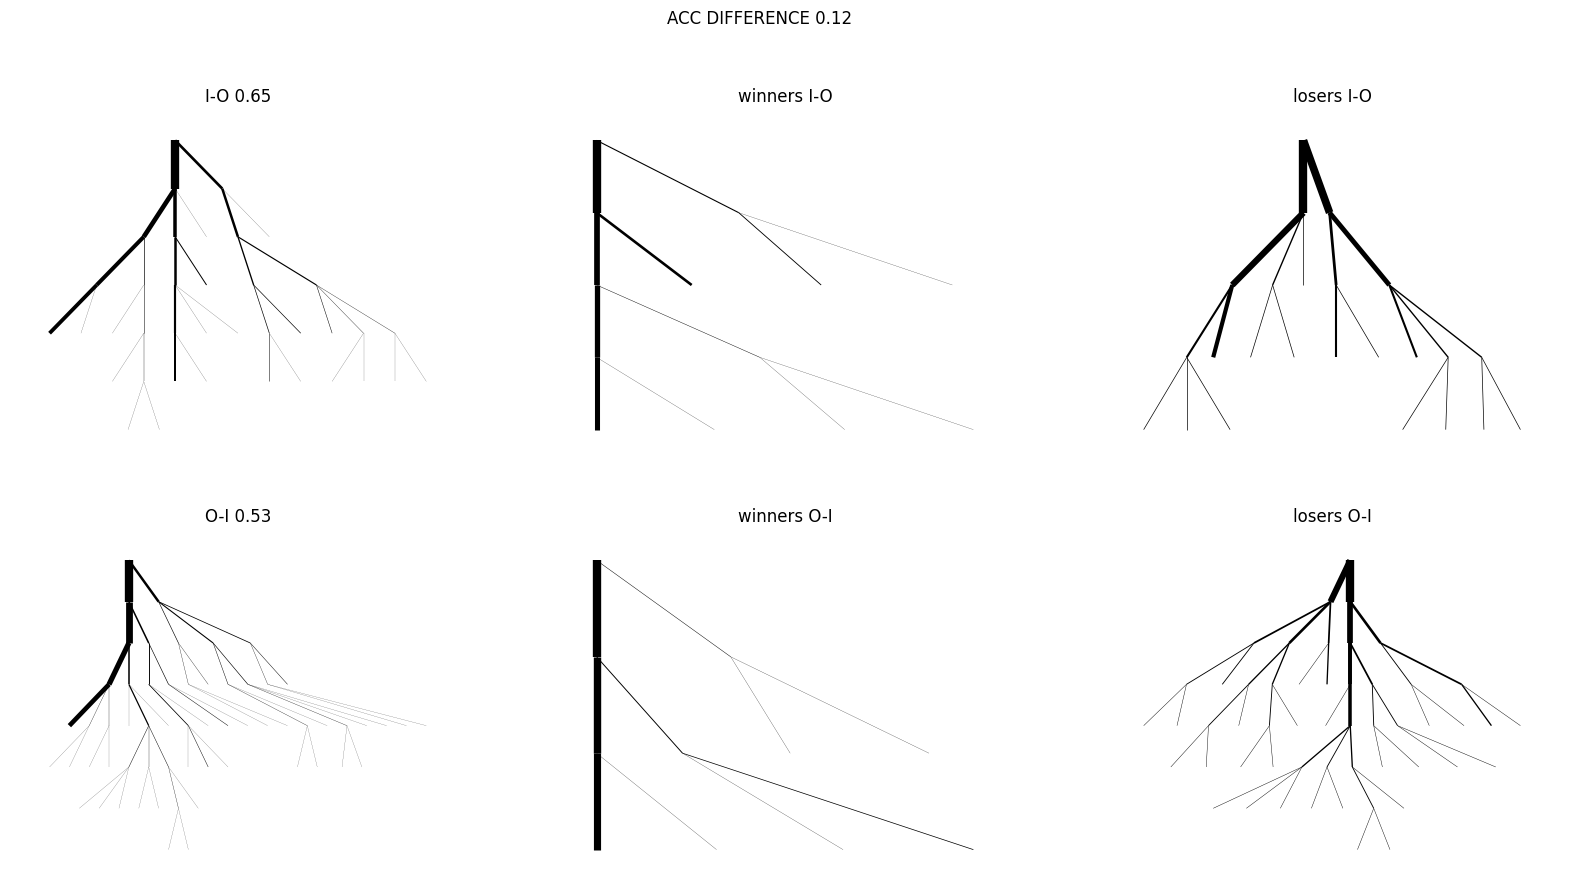

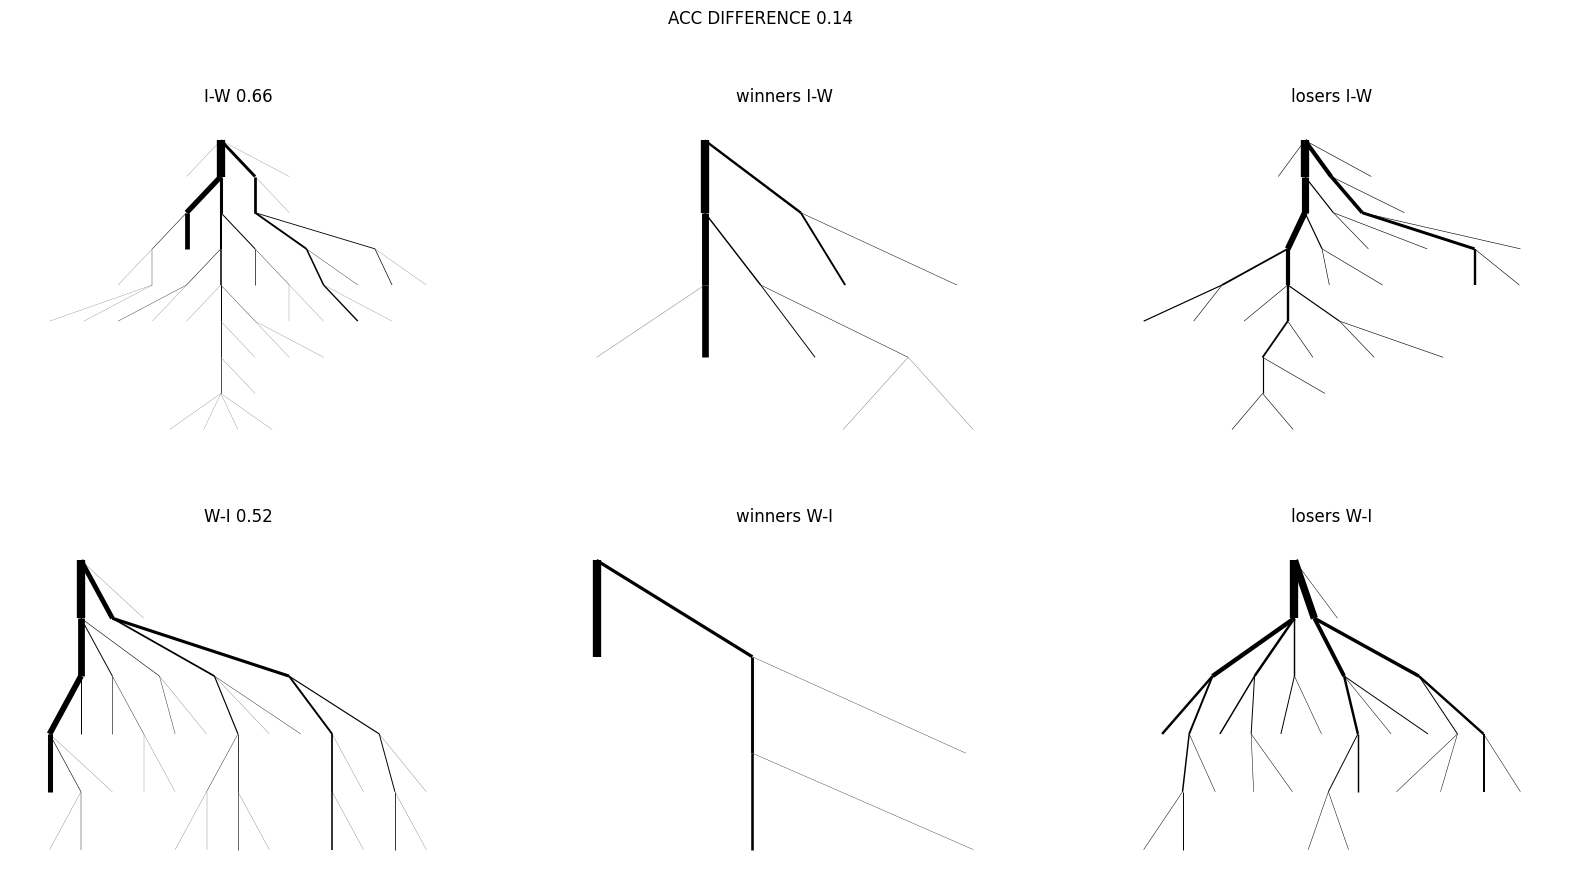

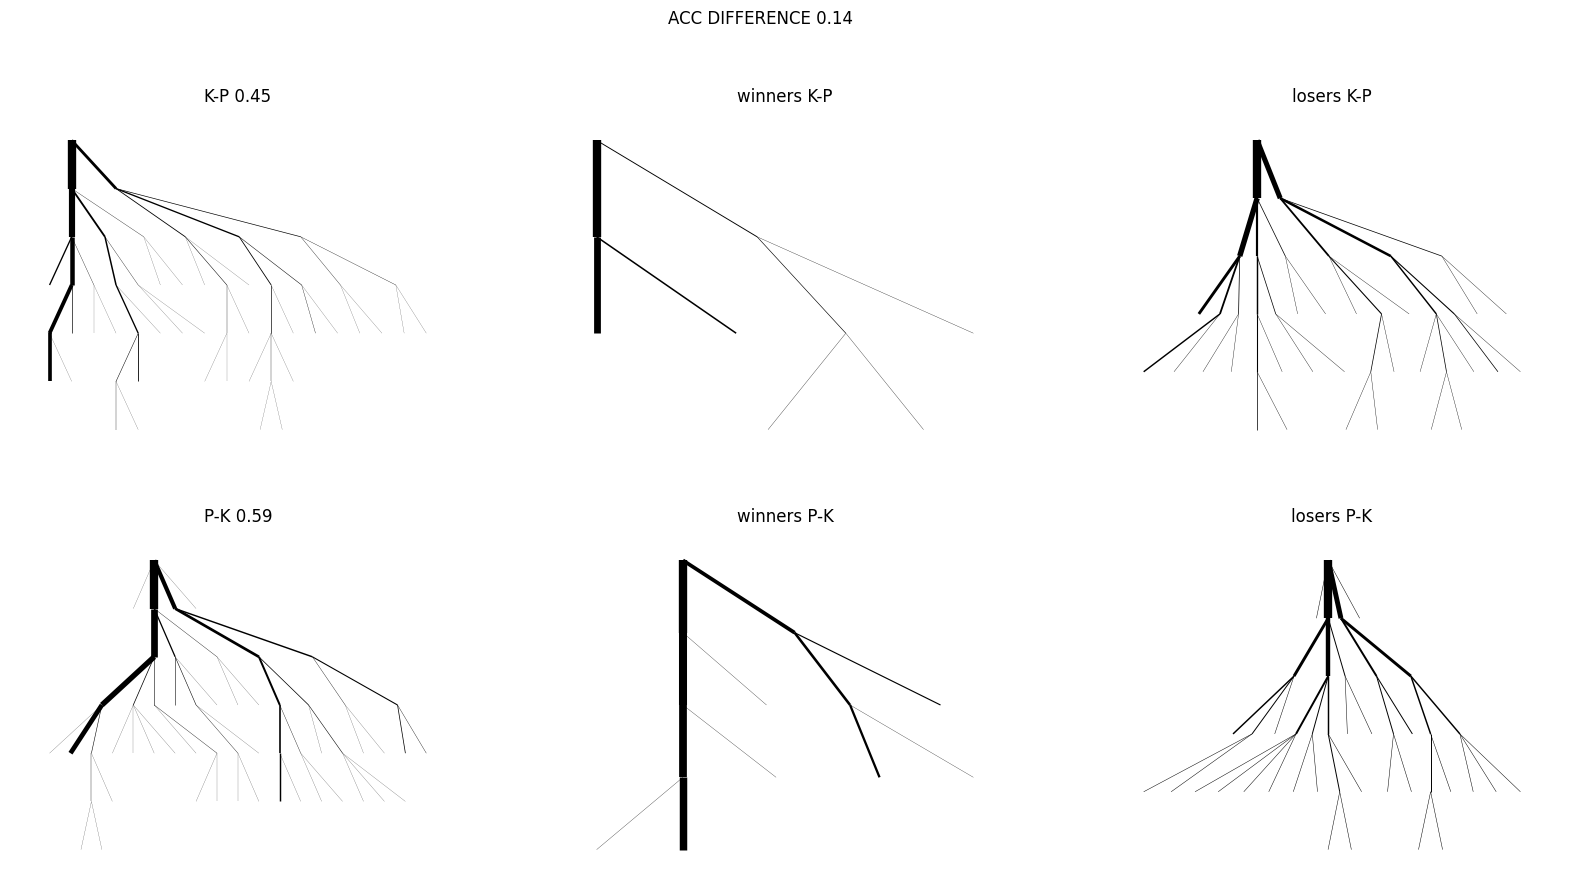

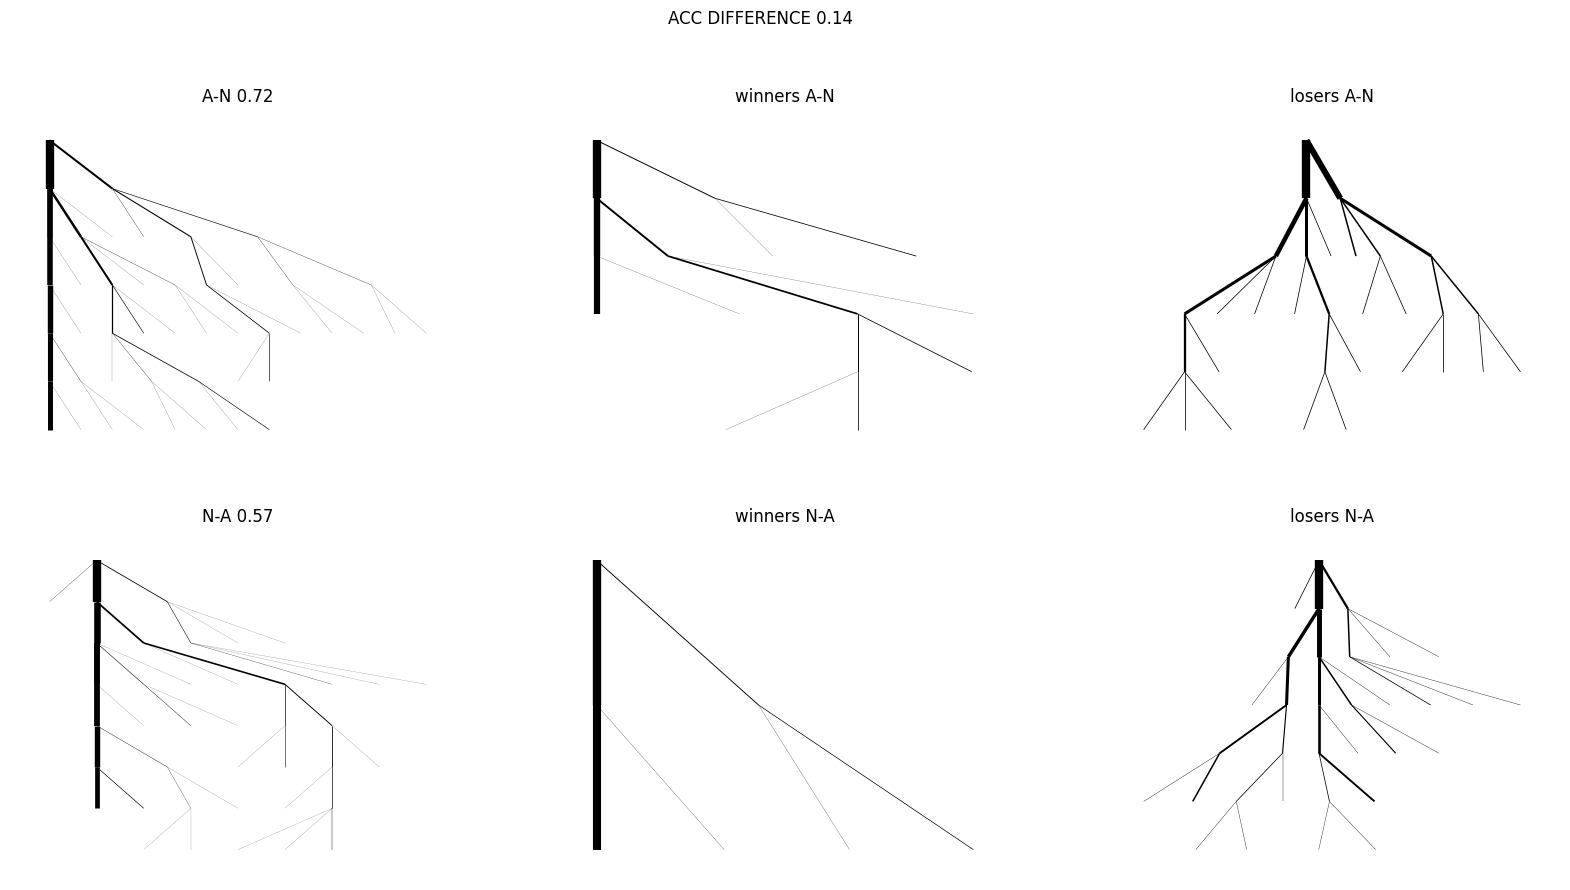

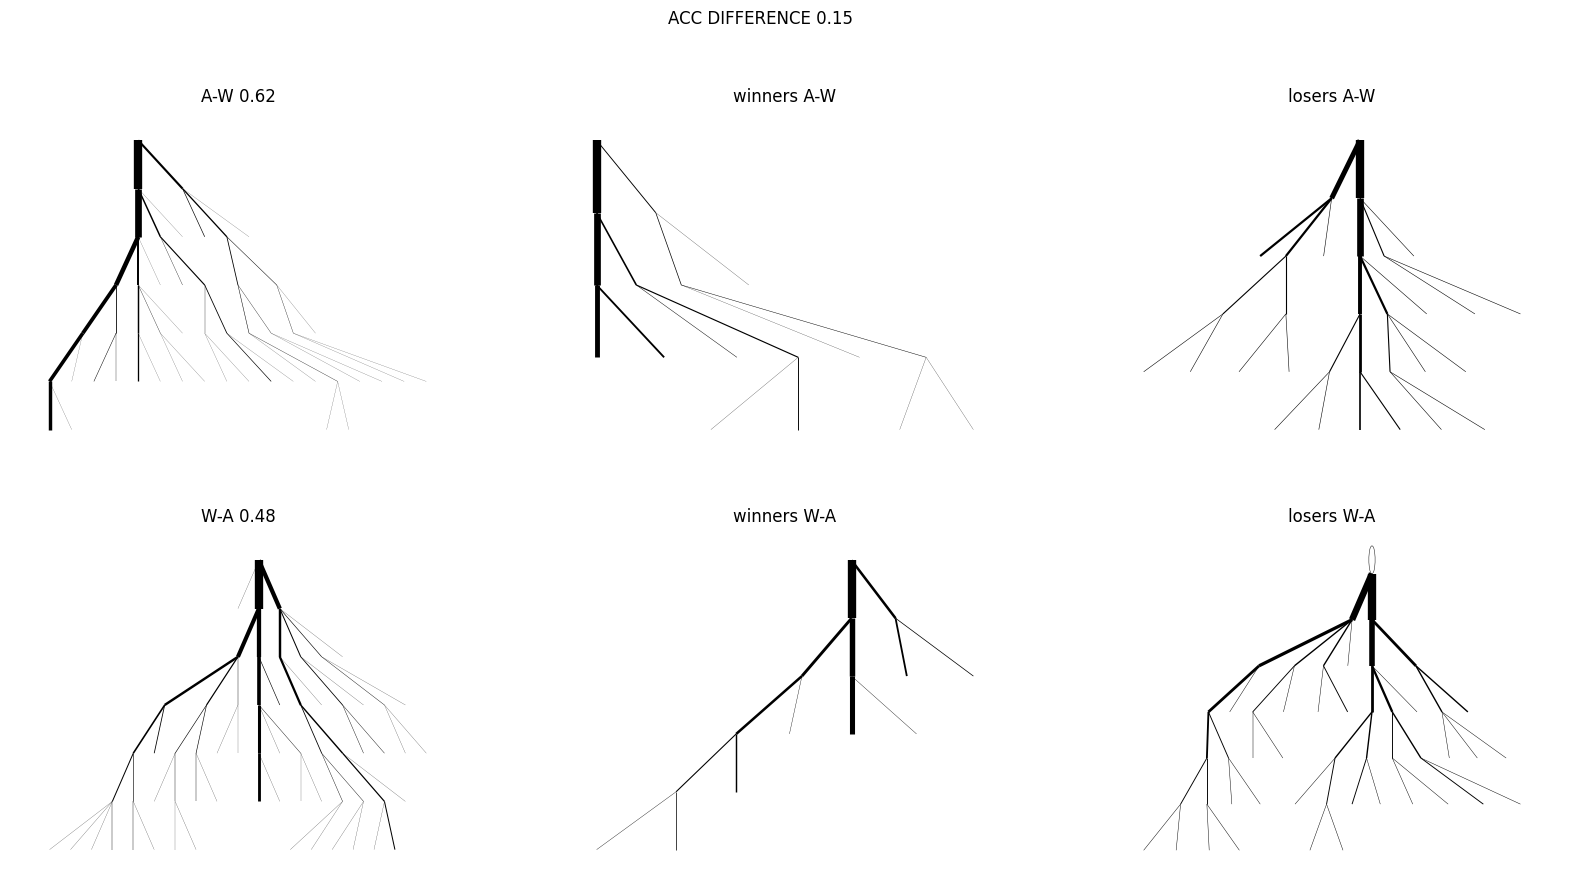

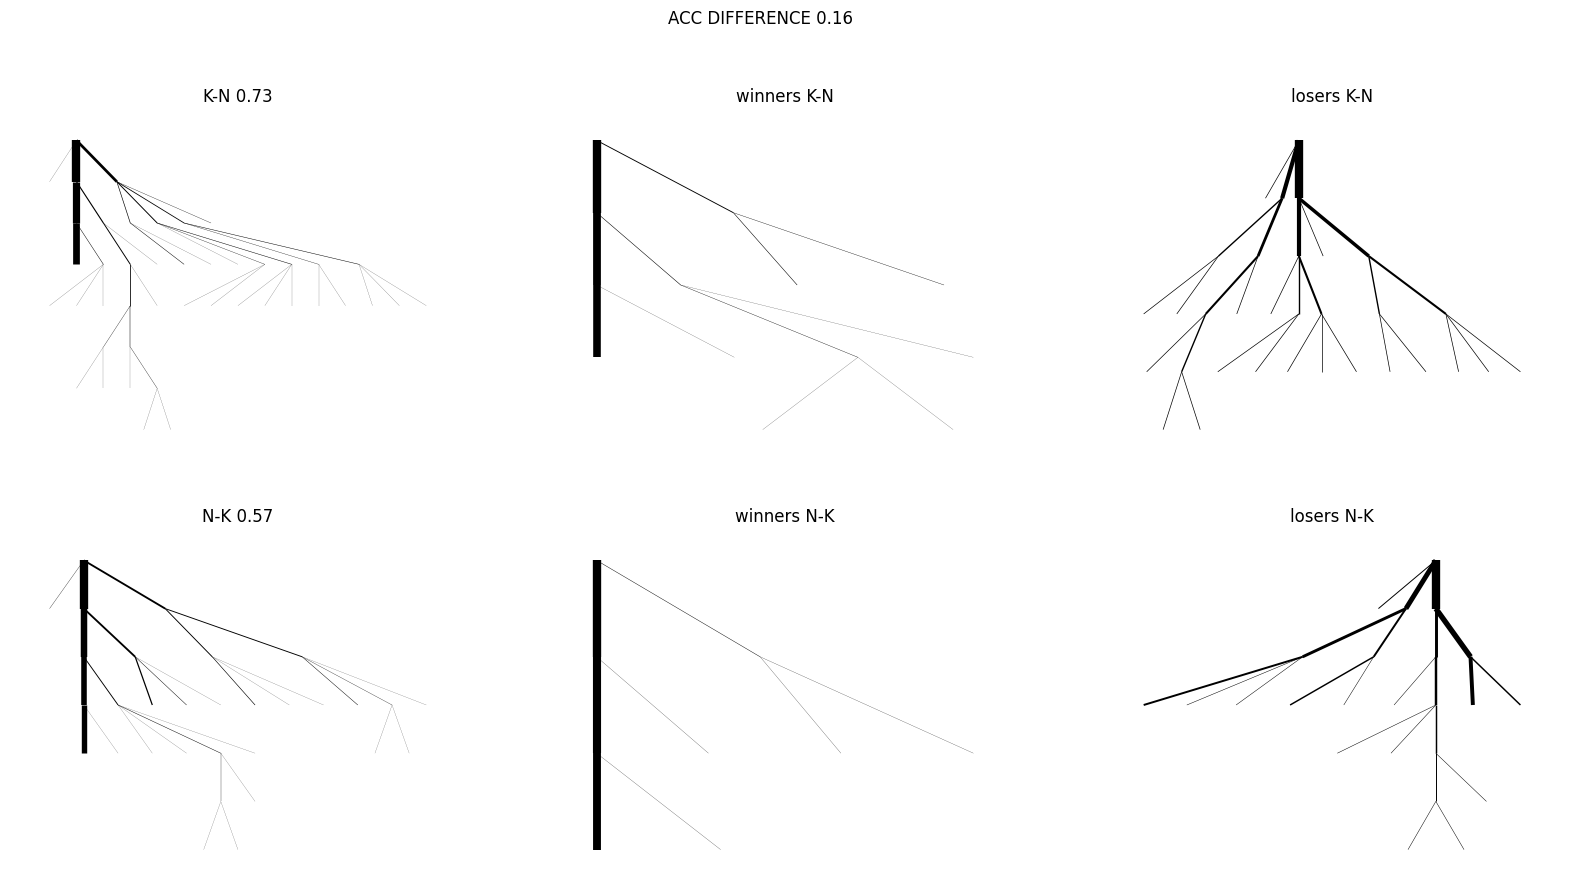

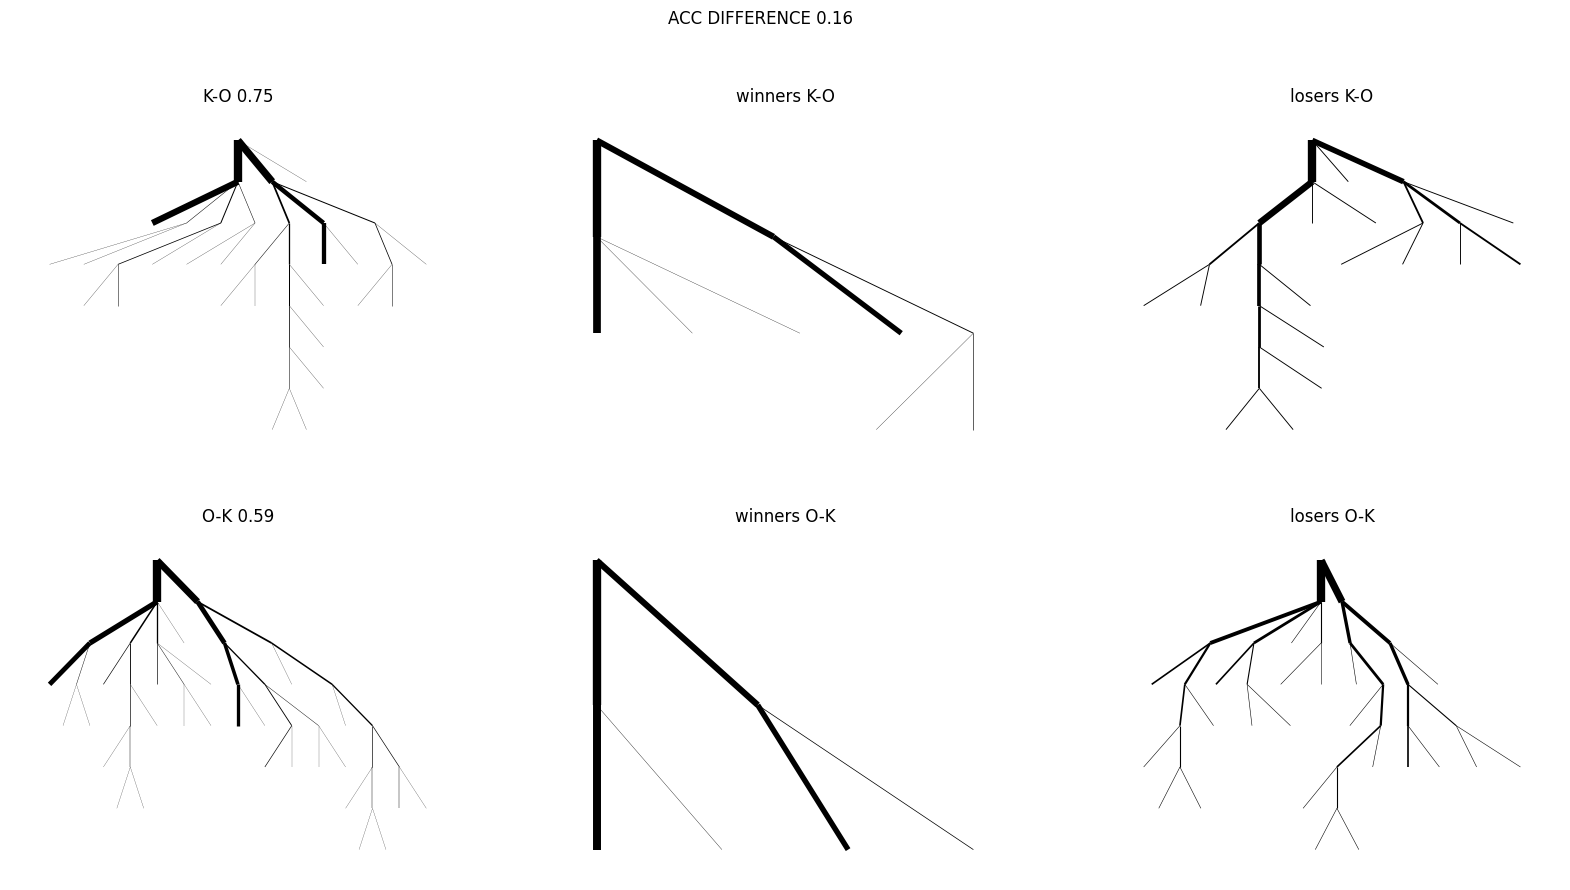

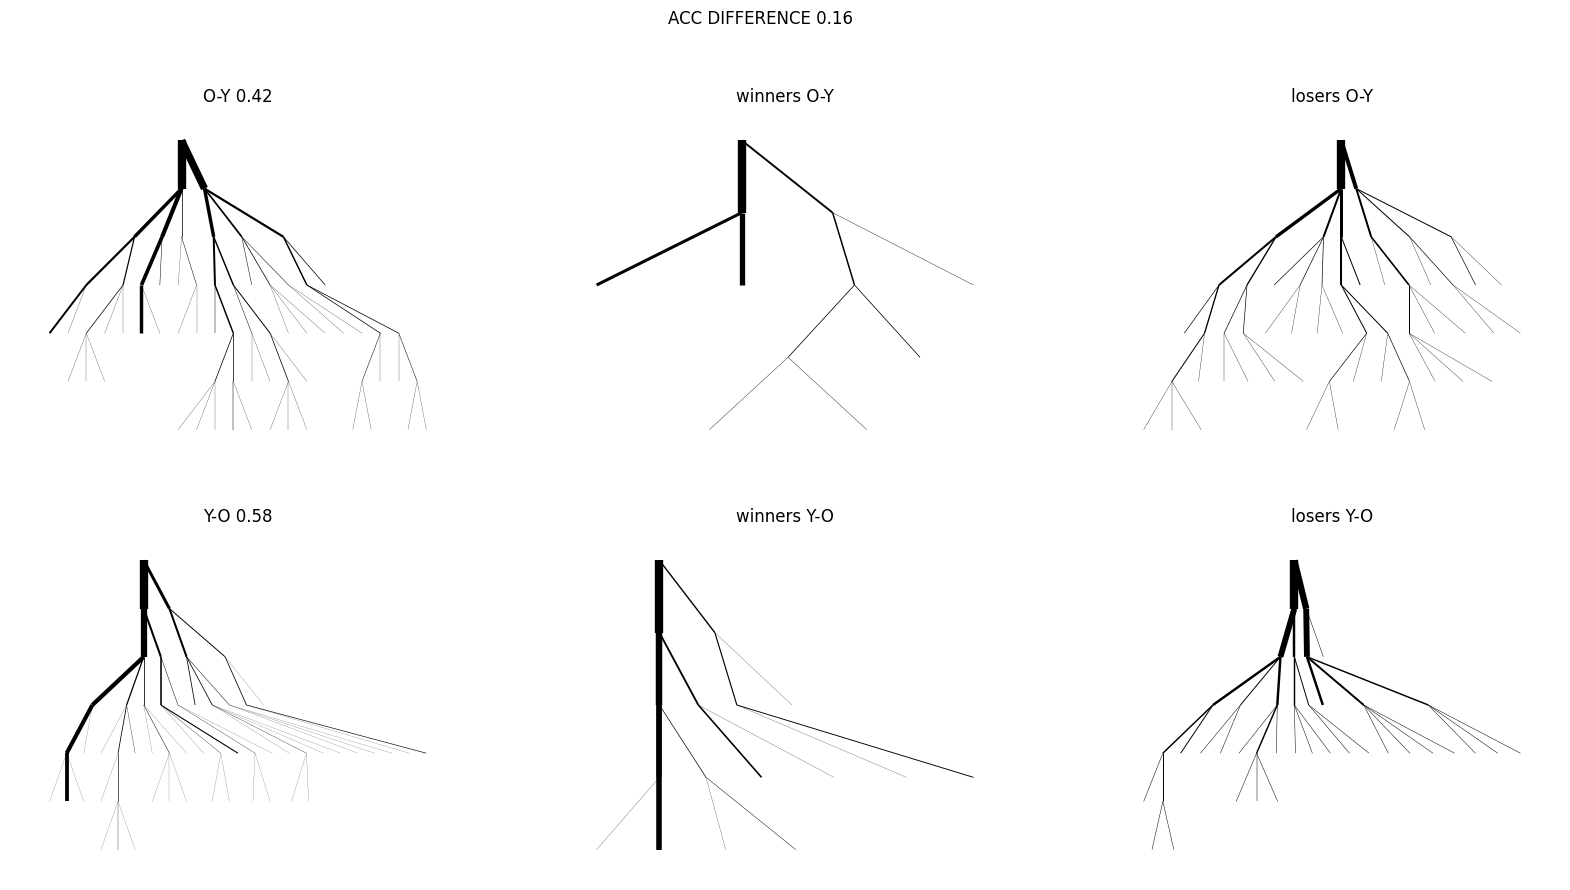

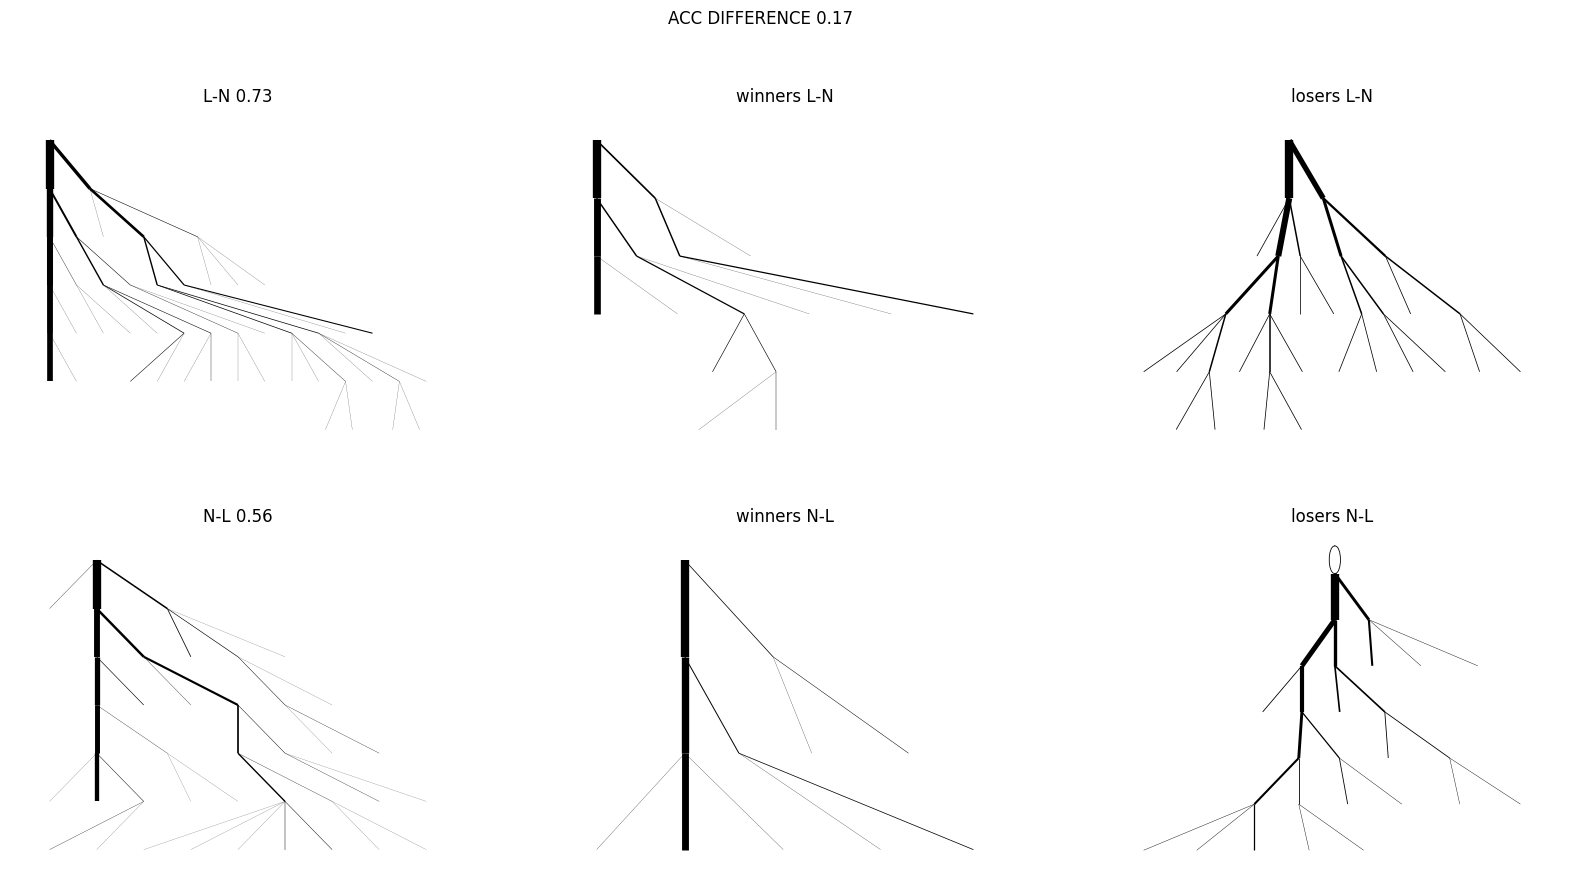

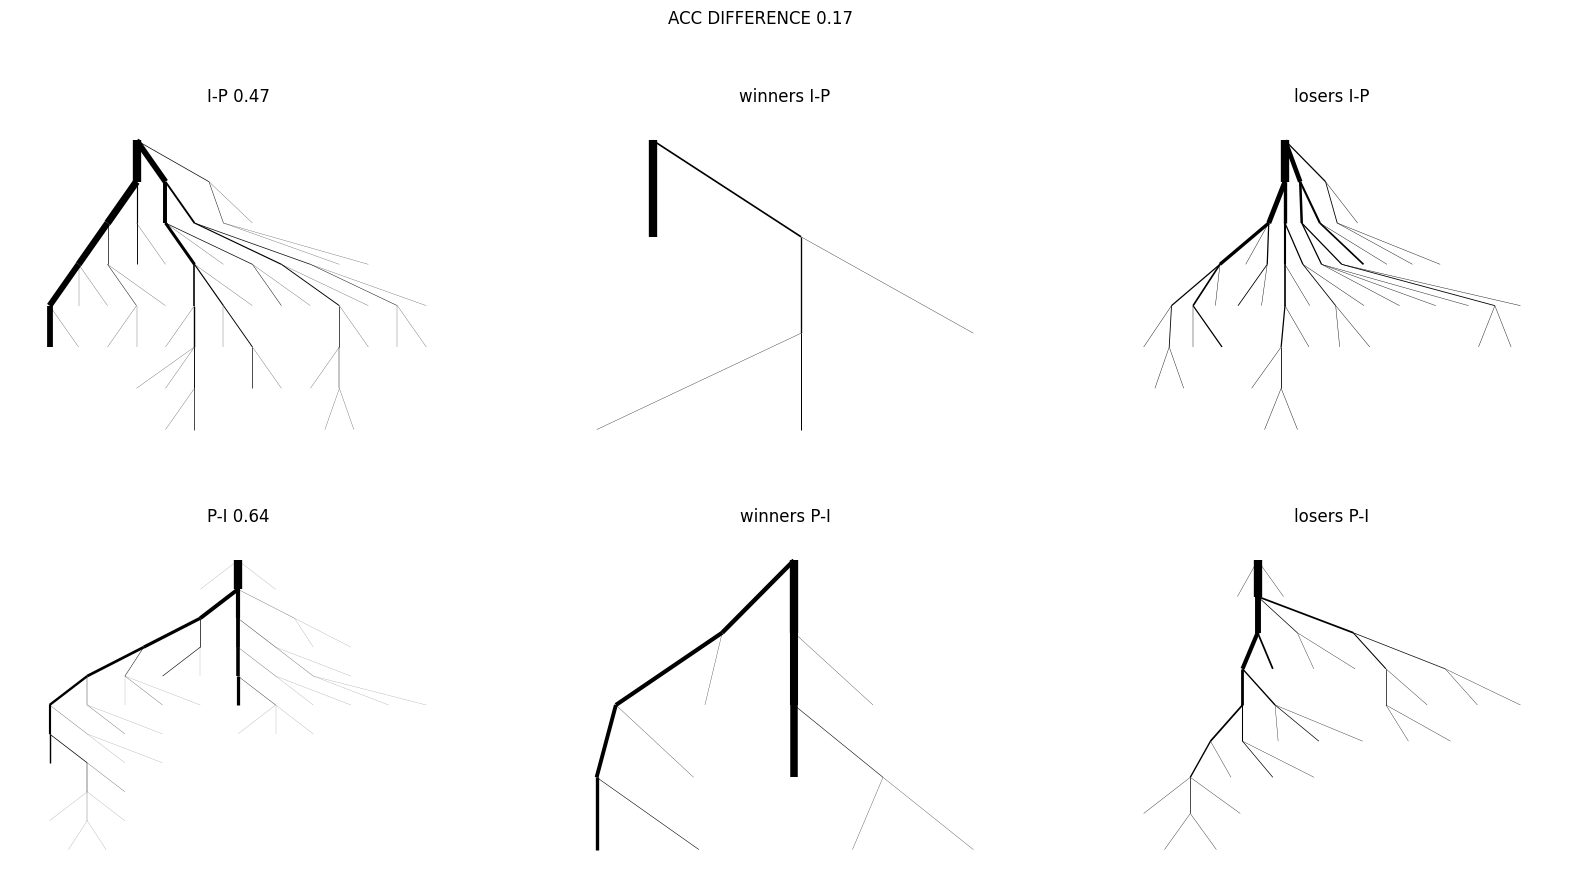

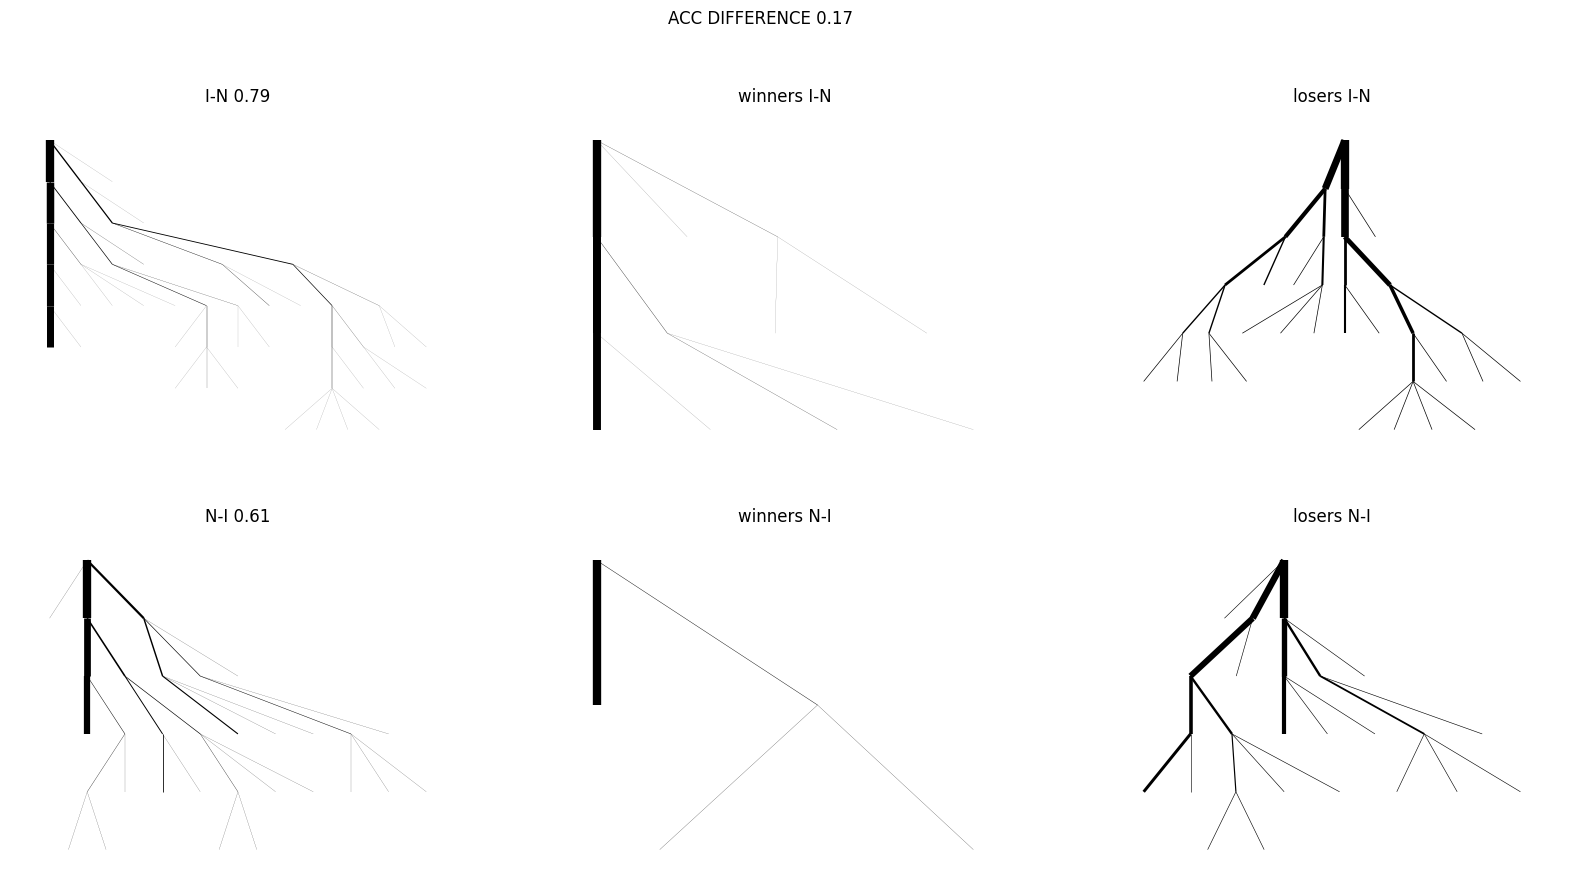

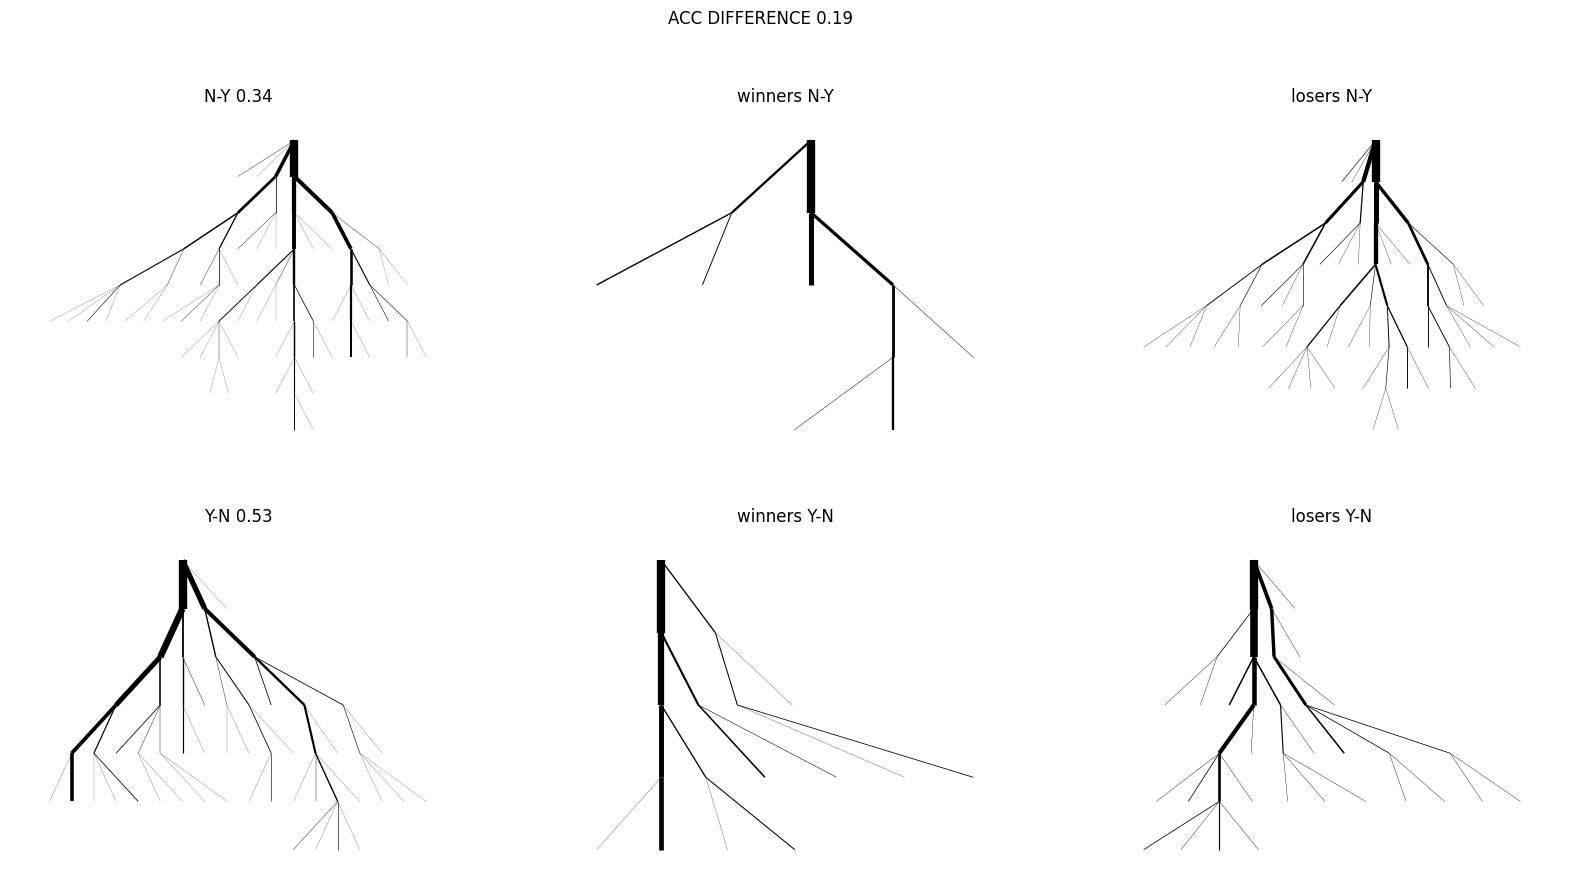

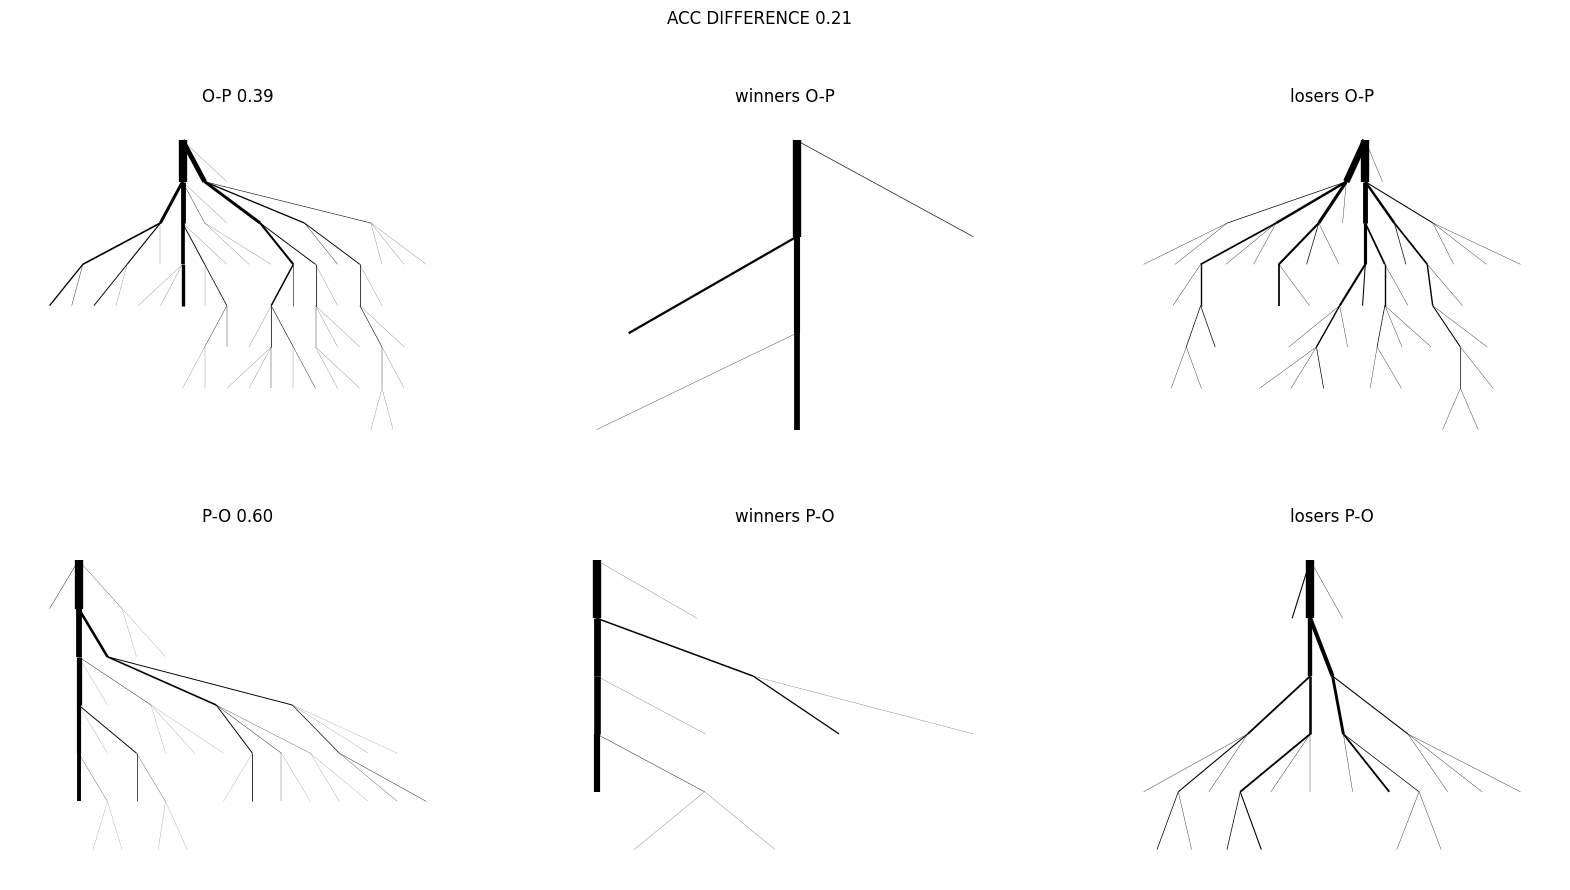

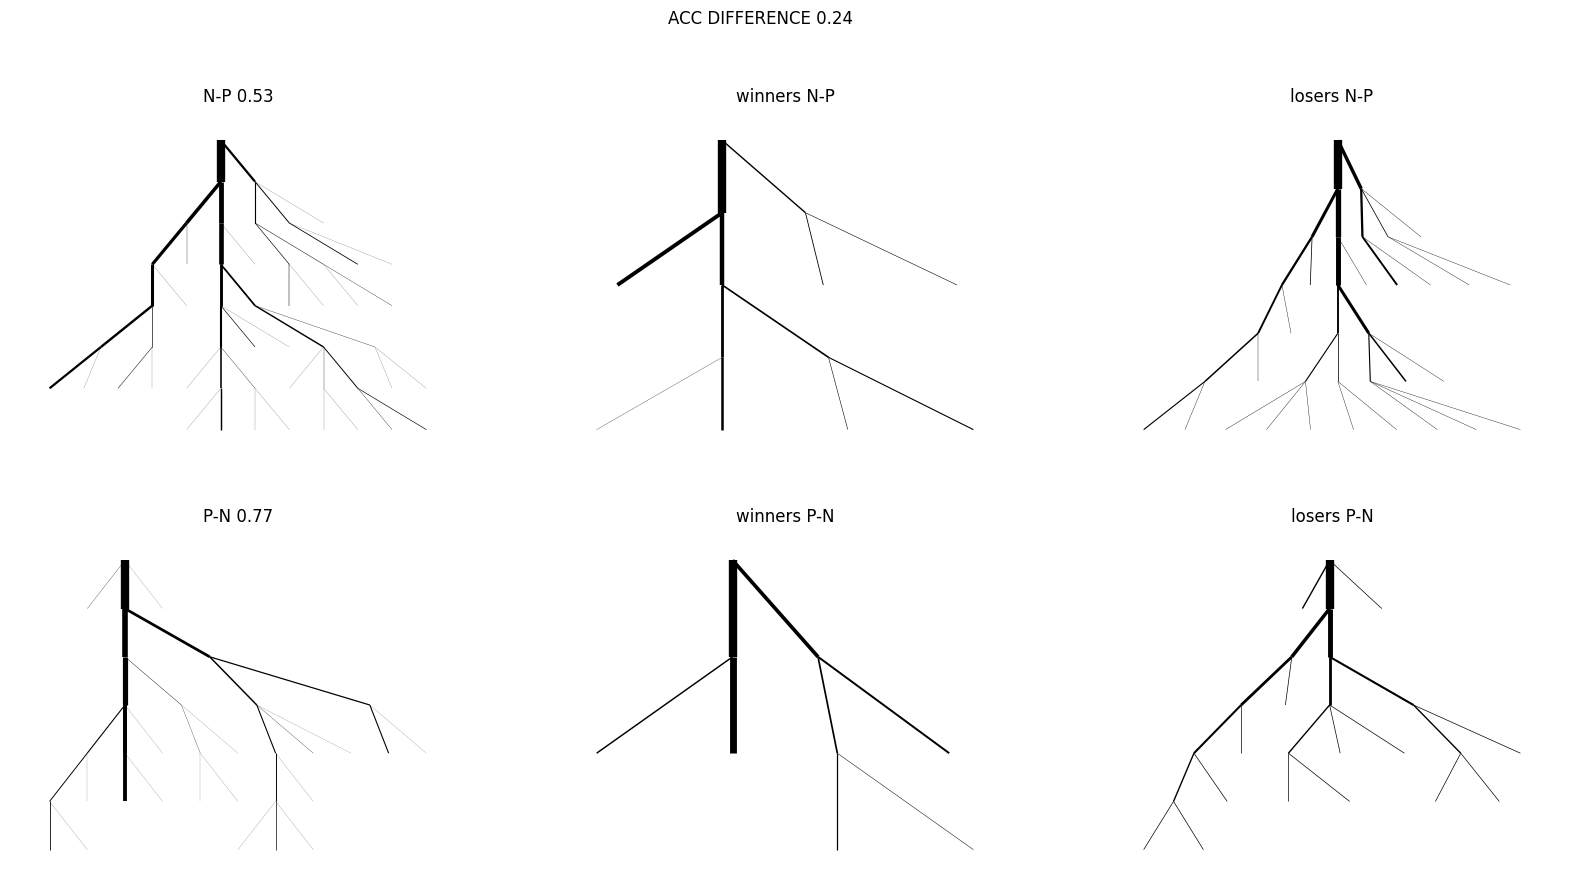

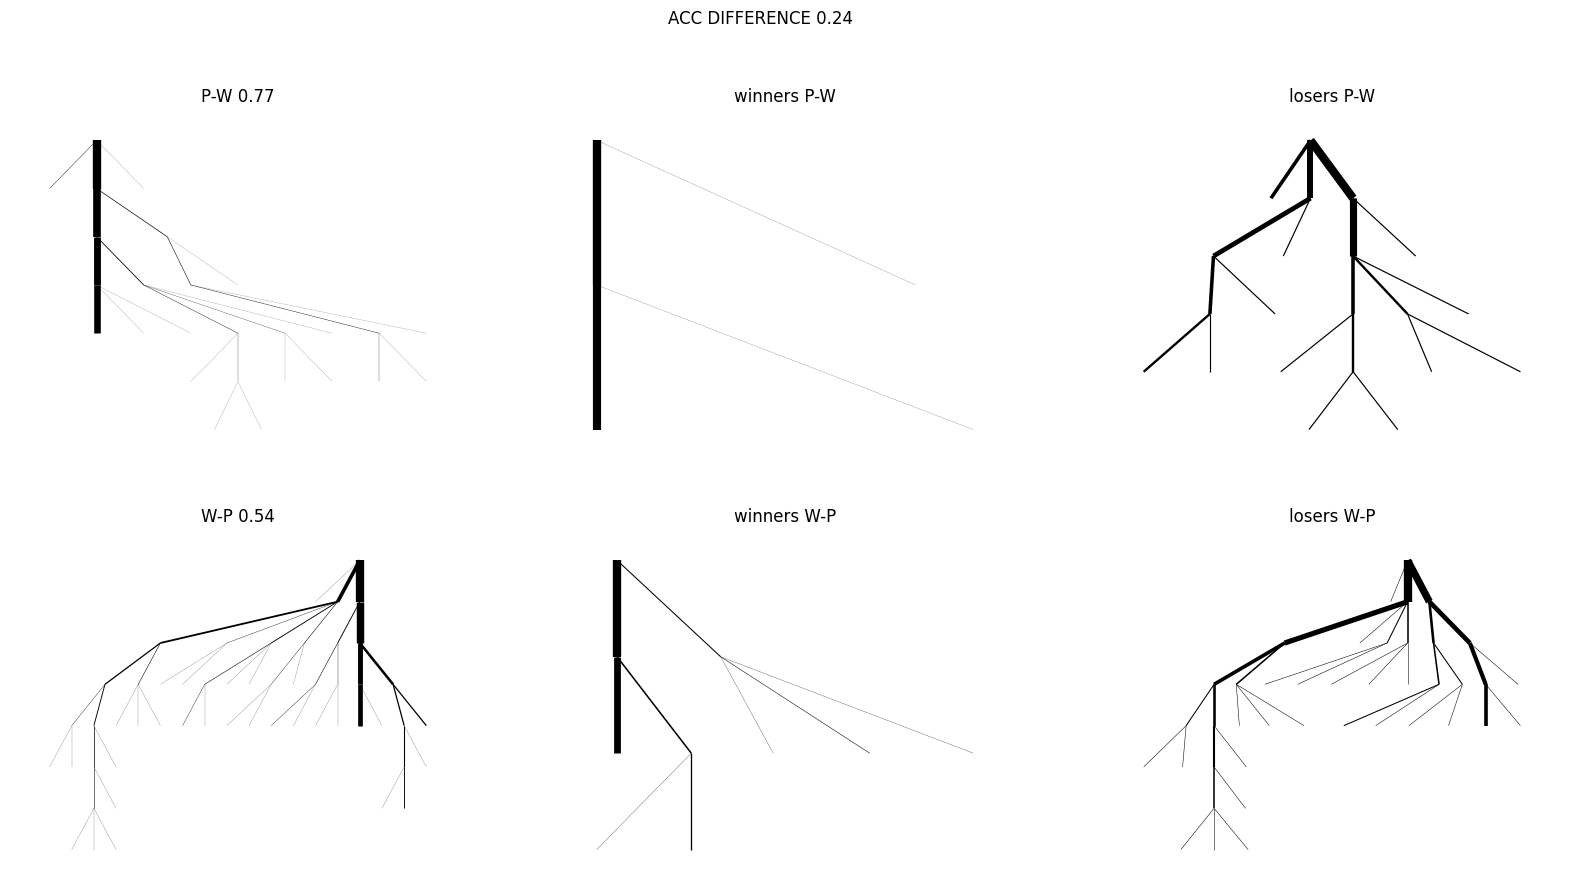

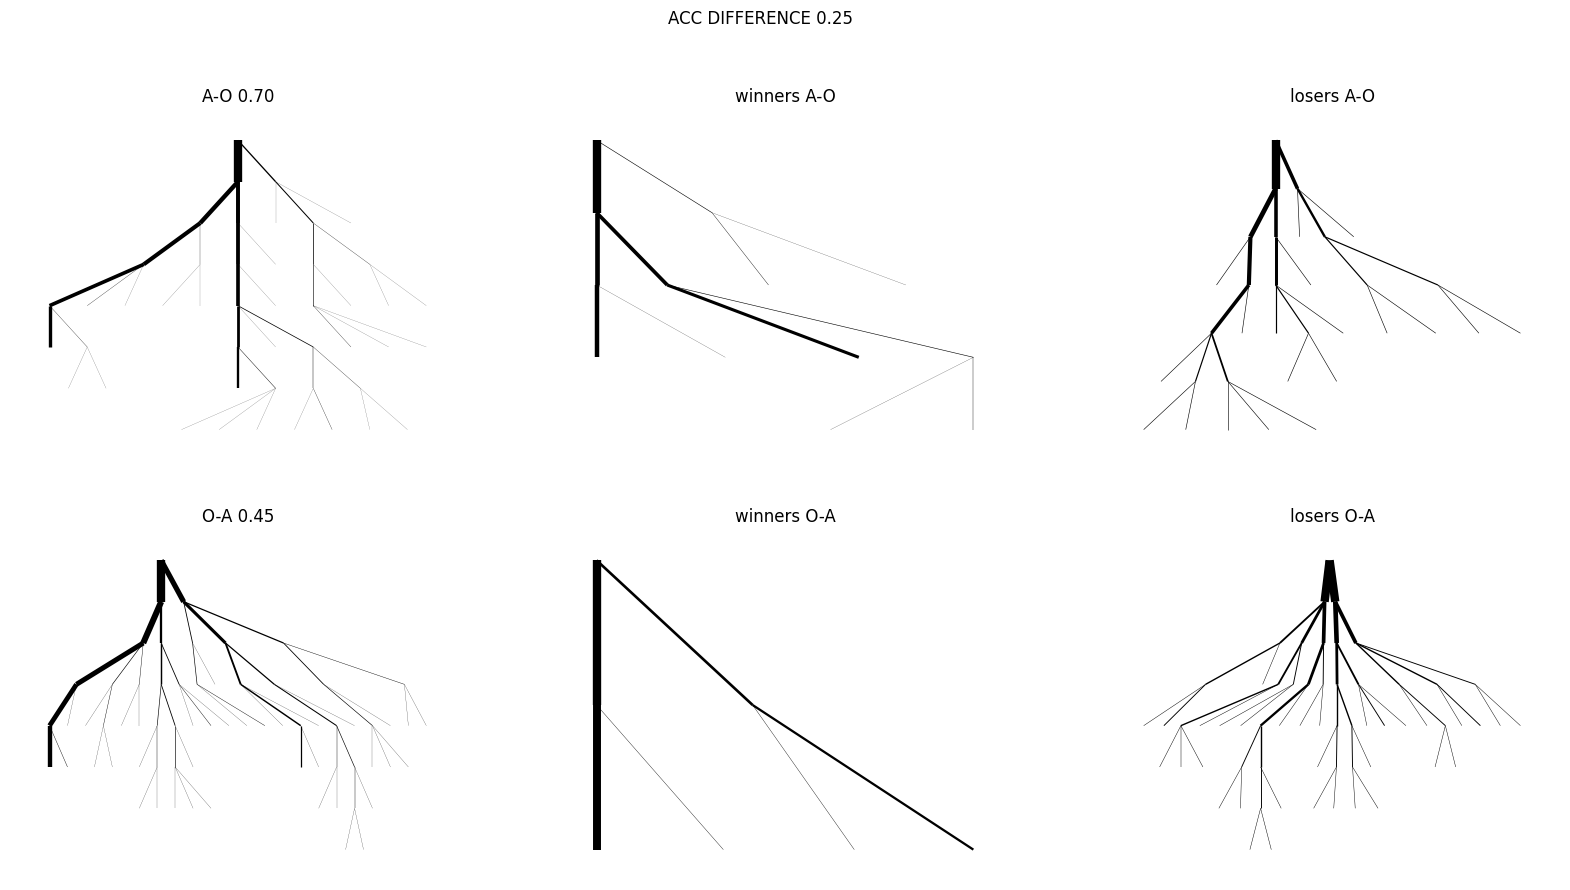

In [19]:
OBJECTS = "AIKLNOPWY"

acc_diffs = []
obj_pairs = []
for i in range(len(OBJECTS) - 1):
    for j in range(i+1, len(OBJECTS)):
        object_a, object_b = OBJECTS[i], OBJECTS[j] 

        acc_diffs.append(np.abs(tree_dict[(object_a, object_b)][1] - tree_dict[(object_b, object_a)][1]))
        obj_pairs.append((object_a, object_b))
        

sorted_order = [x for x in sorted(range(len(acc_diffs)), key=lambda x: acc_diffs[x])]
for i, tree_index in enumerate(sorted_order):
    object_a, object_b = obj_pairs[tree_index]
    
    fig, axes = plt.subplots(2, 3, figsize=(20,10))

    G, acc = tree_dict[(object_a, object_b)]
    plot_flow_tree(G, f"{object_a}-{object_b} {acc:.2f}", axes[0][0], just_edges=True)

    G, acc = tree_dict[(object_b, object_a)]
    plot_flow_tree(G, f"{object_b}-{object_a} {acc:.2f}", axes[1][0], just_edges=True)

    G = winner_tree_dict[(object_a, object_b)]
    plot_flow_tree(G, f"winners {object_a}-{object_b}", axes[0][1], just_edges=True)

    G = winner_tree_dict[(object_b, object_a)]
    plot_flow_tree(G, f"winners {object_b}-{object_a}", axes[1][1], just_edges=True)

    G = loser_tree_dict[(object_a, object_b)]
    plot_flow_tree(G, f"losers {object_a}-{object_b}", axes[0][2], just_edges=True)

    G = loser_tree_dict[(object_b, object_a)]
    plot_flow_tree(G, f"losers {object_b}-{object_a}", axes[1][2], just_edges=True)

    fig.suptitle(f"ACC DIFFERENCE {acc_diffs[tree_index]:.2f}")

    fig.savefig(f"figures/pairs/flow_tree_{object_a}-{object_b}.png")

    plt.show()

### 4. Questions


1. Is palindrome more common among winners than losers?? Is it predictive of success?
2. Did anyone who got it right go into an object?
3. Maybe the people who got it wrong did?
4. Look for particular foil? Will all losers end up at the same wrong place? What are the most common foils?? Is there systematic? Why are there consistent wrong places?
5. Do they get it wrong bc they end up at same place bc they take paths that get them to the wrong spot?
6. Are entropy of leaves and entropy of tree correlated? Especially for losers


#### Palindromes

Winners w/ palindrome: total=218 mean=0.08
Losers w/ palindrome: total=665 mean=0.33


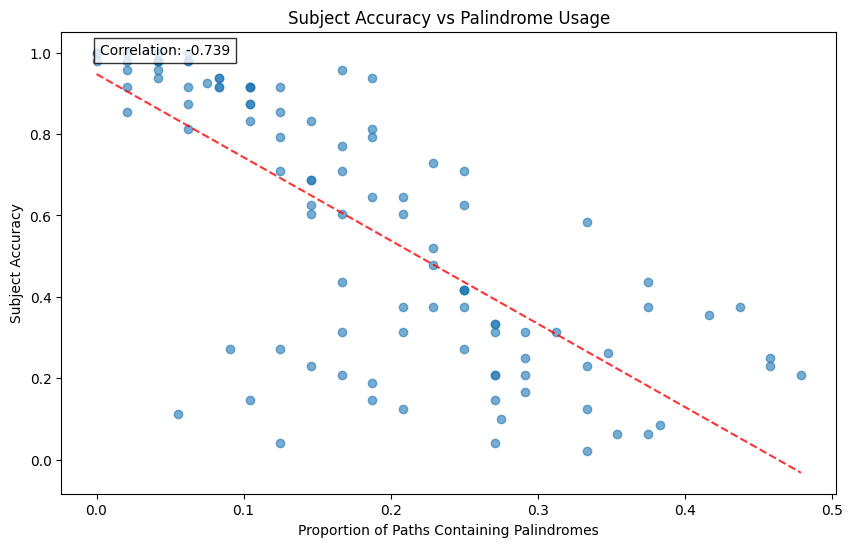

In [22]:
def contains_palindrome(traj):
    for i in range(len(traj)-2):
        if traj[i] == traj[i+2]:
            return True
    return False

winner_palindromes = []
loser_palindromes = []
for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    trajs = generate_trajs_from_df(group)
    accs = np.array(group["accuracy"])
    
    for traj, acc in zip(trajs, accs):
        if acc:
            winner_palindromes.append(contains_palindrome(traj))
        else:
            loser_palindromes.append(contains_palindrome(traj))
    
print(f"Winners w/ palindrome: total={np.sum(winner_palindromes)} mean={np.mean(winner_palindromes):.2f}")
print(f"Losers w/ palindrome: total={np.sum(loser_palindromes)} mean={np.mean(loser_palindromes):.2f}")

# Group by subject and calculate palindrome ratio and accuracy
subject_stats = []
for subject, group in test_df.groupby("Subject"):
    trajs = generate_trajs_from_df(group)
    palindrome_ratio = np.mean([contains_palindrome(traj) for traj in trajs])
    accuracy = np.mean(group["accuracy"])
    subject_stats.append({
        "subject": subject,
        "palindrome_ratio": palindrome_ratio,
        "accuracy": accuracy
    })

# Convert to DataFrame for plotting
stats_df = pd.DataFrame(subject_stats)

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(stats_df["palindrome_ratio"], stats_df["accuracy"], alpha=0.6)
plt.xlabel("Proportion of Paths Containing Palindromes")
plt.ylabel("Subject Accuracy")
plt.title("Subject Accuracy vs Palindrome Usage")

# Add trend line
z = np.polyfit(stats_df["palindrome_ratio"], stats_df["accuracy"], 1)
p = np.poly1d(z)
x_trend = np.linspace(stats_df["palindrome_ratio"].min(), stats_df["palindrome_ratio"].max(), 100)
plt.plot(x_trend, p(x_trend), "r--", alpha=0.8)

# Calculate and display correlation
correlation = stats_df["palindrome_ratio"].corr(stats_df["accuracy"])
plt.text(0.05, 0.95, f"Correlation: {correlation:.3f}", 
         transform=plt.gca().transAxes, 
         bbox=dict(facecolor='white', alpha=0.8))

plt.show()

#### Objects

In [45]:
OBJECTS = "AIKLNOPWY"

def contains_other_obj(traj, start, end):
    for obj in OBJECTS:
        if obj != start and obj != end:
            if obj in traj:
                return True
    return False

winner_objects = []
loser_objects = []
loser_end_object = []
loser_ends = {}
for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    trajs = generate_trajs_from_df(group)
    accs = np.array(group["accuracy"])
    
    for traj, acc in zip(trajs, accs):
        if acc:
            winner_objects.append(contains_other_obj(traj[:-2], start_node, end_node))
        else:
            loser_objects.append(contains_other_obj(traj[:-2], start_node, end_node)) # sometimes it is double end bc button?
            
            end_node = traj[-1][-1]
            loser_end_object.append(end_node in OBJECTS)

            loser_ends[end_node] = loser_ends.get(end_node, 0) + 1


    
print(f"Winners w/ other object: total={np.sum(winner_objects)} mean={np.mean(winner_objects):.2f}")
print(f"Losers w/ other object not end: total={np.sum(loser_objects)} mean={np.mean(loser_objects):.2f}")
print(f"Losers end other object: total={np.sum(loser_end_object)} mean={np.mean(loser_end_object):.2f}")

Winners w/ other object: total=67 mean=0.02
Losers w/ other object not end: total=264 mean=0.13
Losers end other object: total=1285 mean=0.63


#### Looking for common foils

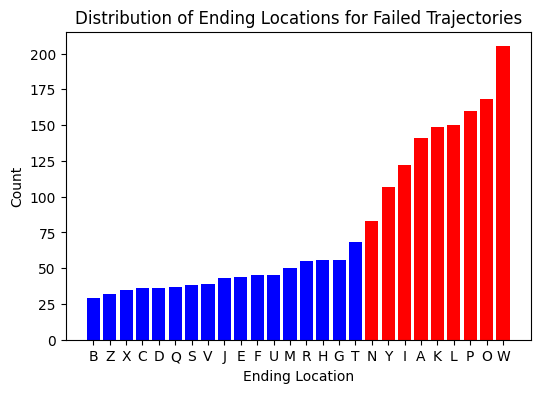

In [47]:
plt.figure(figsize=(6, 4))

# Sort the data by count
sorted_items = sorted(loser_ends.items(), key=lambda x: x[1])
locations, counts = zip(*sorted_items)

# Create color list - objects in red, other locations in blue
colors = ['red' if loc in OBJECTS else 'blue' for loc in locations]

plt.bar(locations, counts, color=colors)
plt.title("Distribution of Ending Locations for Failed Trajectories")
plt.xlabel("Ending Location")
plt.ylabel("Count")
plt.show()


Most common failure modes:
--------------------------------------------------
Target: A            | Most common failure: L            | Count:   36 | Pct: 0.14
Target: I            | Most common failure: K            | Count:   31 | Pct: 0.13
Target: K            | Most common failure: O            | Count:   36 | Pct: 0.15
Target: L            | Most common failure: A            | Count:   32 | Pct: 0.15
Target: N            | Most common failure: F            | Count:   18 | Pct: 0.11
Target: O            | Most common failure: K            | Count:   39 | Pct: 0.20
Target: P            | Most common failure: Y            | Count:   43 | Pct: 0.16
Target: W            | Most common failure: P            | Count:   28 | Pct: 0.15
Target: Y            | Most common failure: W            | Count:   34 | Pct: 0.12
--------------------------------------------------


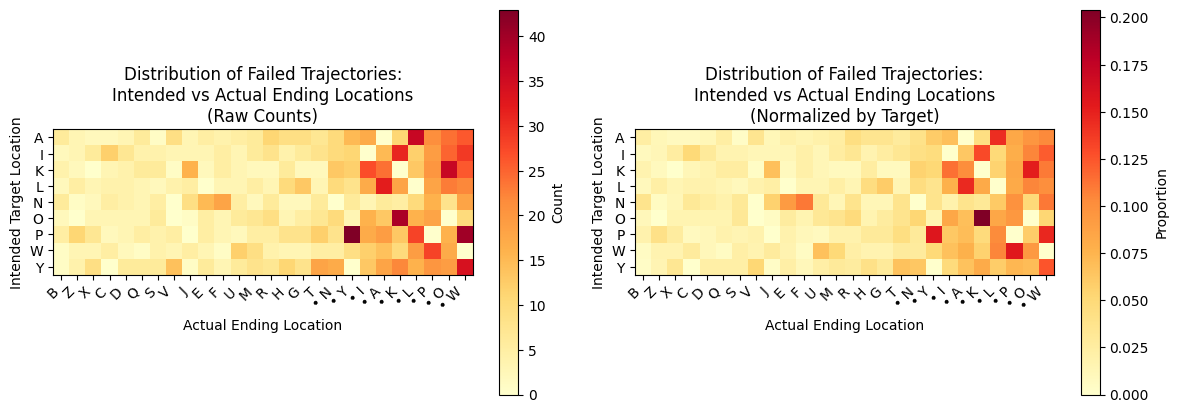

In [52]:
# Create a 2D grid of actual vs intended end locations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))

# Get unique end locations - objects only for y-axis (intended targets)
target_locations = sorted(set(OBJECTS))

# Sort actual locations by frequency like in bar plot
actual_locations = [loc for loc, _ in sorted(loser_ends.items(), key=lambda x: x[1])]
# Add any missing locations from test_df that weren't in loser_ends
remaining_locs = set(test_df['EndAt'].unique()) - set(actual_locations)
actual_locations.extend(sorted(remaining_locs))

# Create a matrix of counts
counts_matrix = np.zeros((len(target_locations), len(actual_locations)))

# Fill the matrix
for (_, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    trajs = generate_trajs_from_df(group)
    for traj in trajs:
        actual_end = traj[-1][-1]
        if actual_end != end_node:  # Only count failures
            i = target_locations.index(end_node)
            j = actual_locations.index(actual_end)
            counts_matrix[i, j] += 1

# Create normalized matrix
norm_matrix = counts_matrix / counts_matrix.sum(axis=1, keepdims=True)

# Print max failure count for each intended target
print("\nMost common failure modes:")
print("-" * 50)
for i, target in enumerate(target_locations):
    max_count = counts_matrix[i].max()
    max_idx = counts_matrix[i].argmax()
    actual = actual_locations[max_idx]
    max_norm = norm_matrix[i][max_idx]
    print(f"Target: {target:12} | Most common failure: {actual:12} | Count: {int(max_count):4} | Pct: {max_norm:.2f}")
print("-" * 50)


# Create heatmaps
for ax, matrix, title_suffix, label in [
    (ax1, counts_matrix, 'Raw Counts', 'Count'),
    (ax2, norm_matrix, 'Normalized by Target', 'Proportion')
]:
    im = ax.imshow(matrix, cmap='YlOrRd')
    plt.colorbar(im, ax=ax, label=label, shrink=0.5)
    
    # Set labels with different colors for objects vs other locations
    x_labels = [f'\u2022 {loc}' if loc in OBJECTS else loc for loc in actual_locations]
    ax.set_xticks(range(len(actual_locations)))
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    ax.set_yticks(range(len(target_locations)))
    ax.set_yticklabels(target_locations)
    
    ax.set_xlabel('Actual Ending Location')
    ax.set_ylabel('Intended Target Location')
    ax.set_title(f'Distribution of Failed Trajectories:\nIntended vs Actual Ending Locations\n({title_suffix})')

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()


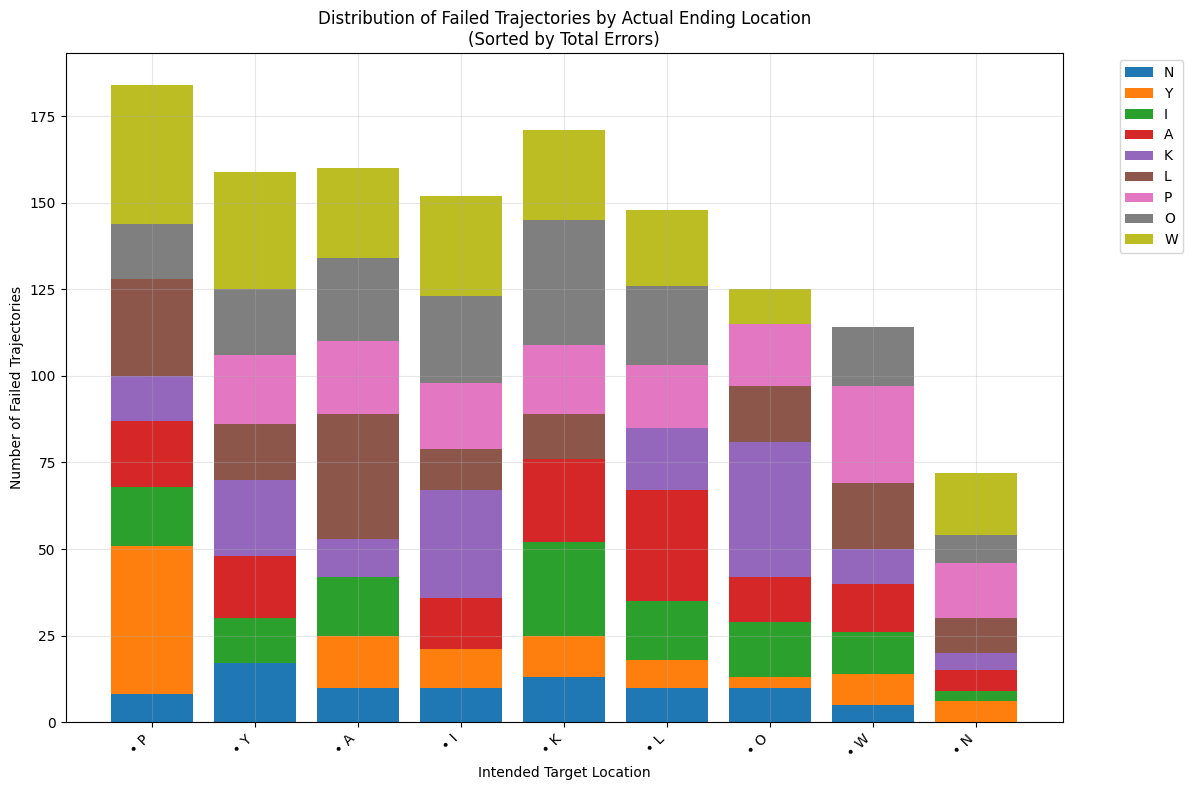

In [62]:
only_use_objects = True

# Create a figure
plt.figure(figsize=(12, 8))

# Calculate total errors for each target location
total_errors = counts_matrix.sum(axis=1)
sorted_indices = np.argsort(total_errors)[::-1]  # Sort in descending order

# Create stacked bar plot
bottom = np.zeros(len(target_locations))
for i, actual in enumerate(actual_locations):
    if (not only_use_objects) or (actual in OBJECTS):
        # Use sorted_indices to index into counts_matrix correctly
        values = counts_matrix.T[i][sorted_indices]  # Transpose to get actual location values
        plt.bar(range(len(target_locations)), values,
               bottom=bottom, label=actual)
        bottom += values

# Set x-axis labels with dots for objects, using sorted order
x_labels = [f'\u2022 {target_locations[i]}' if target_locations[i] in OBJECTS else target_locations[i] 
           for i in sorted_indices]
plt.xticks(range(len(target_locations)), x_labels, rotation=45, ha='right')

plt.xlabel('Intended Target Location')
plt.ylabel('Number of Failed Trajectories')
plt.title('Distribution of Failed Trajectories by Actual Ending Location\n(Sorted by Total Errors)')

# Add legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()


#### Tree and leaf entropy

In [73]:
# Calculate entropy for winner/loser trees and final nodes

# Helper function to calculate entropy
def calculate_entropy(counts):
    probabilities = counts / np.sum(counts)
    # Remove zero probabilities to avoid log(0)
    probabilities = probabilities[probabilities > 0]
    return -np.sum(probabilities * np.log2(probabilities))

def calculate_tree_entropy(G):
    # Get all non-leaf nodes (nodes with outgoing edges)
    non_leaf_nodes = [node for node in G.nodes() if len(list(G.neighbors(node))) > 0]
    
    tree_entropy = 0
    for node in non_leaf_nodes:
        # Get outgoing edges and their weights
        edge_weights = [G.edges[node, successor]['weight'] for successor in G.neighbors(node)]
        total_weight = sum(edge_weights)
        
        if total_weight > 0:  # Avoid division by zero
            # Calculate probabilities for each branch
            probabilities = np.array(edge_weights) / total_weight
            
            # Calculate entropy for this node
            node_entropy = -np.sum(probabilities * np.log2(probabilities))
            tree_entropy += node_entropy
    
    return tree_entropy

# Calculate entropy for winner/loser trees
winner_tree_entropies = []
loser_tree_entropies = []

winner_leaf_entropies = []
loser_leaf_entropies = []

accs = []

pairs = []

for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    pairs.append(start_node+end_node)
    trajs = generate_trajs_from_df(group)
    # G = generate_flow_tree_from_trajs(trajs, END_NODE=end_node)

    # new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') # need to do for embeddings
    # flow_trees.append(new_G)
    accs.append(group["path_mean_acc"].iloc[0])
    # paths.append((start_node, end_node))
    # tree_dict[(start_node, end_node)] = [new_G, group["path_mean_acc"].iloc[0]]

    group["accuracy"] = group["accuracy"].astype(bool)

    # WINNERS ONLY
    winner_trajs = generate_trajs_from_df(group[group["accuracy"]])
    winner_ends = [winner_traj[-1] for winner_traj in winner_trajs]
    winner_end_counts = pd.Series(winner_ends).value_counts()
    winner_leaf_entropies.append(calculate_entropy(winner_end_counts))

    G_winner = generate_flow_tree_from_trajs(winner_trajs, END_NODE=end_node)
    winner_tree_entropies.append(calculate_tree_entropy(G_winner))

    # G = generate_flow_tree_from_trajs(trajs, END_NODE=end_node)
    # winner_tree_dict[(start_node, end_node)] = G

    # LOSERS ONLY
    loser_trajs = generate_trajs_from_df(group[~group["accuracy"]])
    loser_ends = [loser_traj[-1] for loser_traj in loser_trajs]
    loser_end_counts = pd.Series(loser_ends).value_counts()
    loser_leaf_entropies.append(calculate_entropy(loser_end_counts))

    G_loser = generate_flow_tree_from_trajs(loser_trajs, END_NODE=end_node)
    loser_tree_entropies.append(calculate_tree_entropy(G_loser))

    # G = generate_flow_tree_from_trajs(trajs, END_NODE=end_node)
    # loser_tree_dict[(start_node, end_node)] = G

# Print mean and variance of leaf entropies
print(f"Winner leaf entropy - Mean: {np.mean(winner_leaf_entropies):.3f}, Variance: {np.var(winner_leaf_entropies):.3f}")
print(f"Loser leaf entropy - Mean: {np.mean(loser_leaf_entropies):.3f}, Variance: {np.var(loser_leaf_entropies):.3f}")
print("Entropy of 3 can mean there are 2^3 equally likely outcomes.")

print(f"Winner tree entropy - Mean: {np.mean(winner_tree_entropies):.3f}, Variance: {np.var(winner_tree_entropies):.3f}")
print(f"Loser tree entropy - Mean: {np.mean(loser_tree_entropies):.3f}, Variance: {np.var(loser_tree_entropies):.3f}")


import plotly.express as px
import plotly.graph_objects as go

# Create a dataframe for plotly
df = pd.DataFrame({
    'Leaf Entropy': loser_leaf_entropies,
    'Tree Entropy': loser_tree_entropies,
    'Mean Accuracy': accs,
    'Pair': pairs
})

# Create scatter plot
fig = px.scatter(df, 
                 x='Leaf Entropy', 
                 y='Tree Entropy',
                 color='Mean Accuracy',
                 hover_data={'Leaf Entropy': ':.3f',
                           'Tree Entropy': ':.3f', 
                           'Mean Accuracy': ':.3f',
                           'Pair': True},
                 opacity=0.6,
                 color_continuous_scale='viridis',
                 title='Loser Leaf Entropy vs Tree Entropy')

# Add diagonal reference line
fig.add_trace(
    go.Scatter(x=[min(loser_leaf_entropies), max(loser_leaf_entropies)],
               y=[min(loser_leaf_entropies), max(loser_leaf_entropies)],
               mode='lines',
               line=dict(dash='dash', color='black', width=1),
               opacity=0.3,
               showlegend=False)
)

# Update layout
fig.update_layout(
    width=1000,
    height=600,
    xaxis_title="Loser Leaf Entropy",
    yaxis_title="Loser Tree Entropy",
    xaxis=dict(range=[min(loser_leaf_entropies), max(loser_leaf_entropies)]),
    coloraxis_colorbar_title="Mean Path Accuracy"
)

fig.show()


Winner leaf entropy - Mean: 0.000, Variance: 0.000
Loser leaf entropy - Mean: 3.476, Variance: 0.089
Entropy of 3 can mean there are 2^3 equally likely outcomes.
Winner tree entropy - Mean: 5.430, Variance: 7.667
Loser tree entropy - Mean: 23.979, Variance: 42.722
